# T51 — North American thermochronology and dynamic topography: constraints on Mesozoic/Cenozoic uplift and exhumation
> **Data availability.** This notebook depends on external dataset(s) that will be distributed via the suite's Zenodo archive, which has not been uploaded yet as of this writing. This notebook will not run until that upload is complete.


**Cluster G: Paleo-geography + paleo-topography.**

*Based on:* 
The workflow of Boone et al. (2025), Communications Earth & Environment 6, 1015. *Deciphering mantle, tectonic and climatic drivers of exhumation* and data of Hillenbrand, I.W. et al. (2023, rev. 2025), *USGS Geochron: A Database of Geochronological and Thermochronological Dates and Data (ver. 4.0)*. U.S. Geological Survey data release, DOI: 10.5066/P9RZNPIF (public domain).

## What this notebook does

Extends the T47 → T48 → T49 → T50 ThermoPlates workflow of Boone et al. (2025) from Central Asia to **continent-scale North America** — a Cordillera-margin + cratonic-interior system whose Mesozoic-Cenozoic uplift history is strongly coupled to the **Farallon slab dynamic-topography signal** (Moucha et al. 2008, Forte et al. 2010, Karlstrom et al. 2012). Dynamic topography is the **primary** geodynamic hypothesis for North American Mesozoic-Cenozoic uplift, and the Young et al. (2022) `gld428` model — which explicitly captures subduction-coupled long-wavelength mantle flow — is well-suited to represent it.

**Sections:**
1. **§1** Load plate model + USGS Geochron v4.0 North American thermochronology compilation.
2. **§2** Per-sample cooling rate at the snapshot age (closure-to-surface reduction — see §1 for the pitfall relative to Boone's per-window `TempDiff`).
3. **§3** Layer A — cooling rates × seafloor age (global orthographic centred on North America).
4. **§4** Layer B — cooling rates × paleotopography (North American regional zoom).
5. **§5** Layer C — cooling rates × Young 2022 `gld428` dynamic-topography uplift rate.
6. **§6** Multi-snapshot orthographic panel: `gld428` uplift rate + NA cooling samples through the Phanerozoic.
7. **§7** Cross-variable correlations — cooling rate vs `gld428` uplift rate, time-series, W vs E split at the Rocky Mountain front.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.
**Runtime**: \~4 min for a single snapshot; \~15 min for the full Phanerozoic time-series sweep at 20-Myr cadence.


## Data availability

**Hillenbrand, I.W., Thomson, K.D., Morgan, L.E., Gilmer, A.K., Engle, Z.T., Miller, A.T., Slawson, J., Dombrowski, A., Warrell, K.F., Malone, J., Souders, A.K., Hudson, A.M., Cosca, M.A., Paces, J.B., Thompson, R.A., and Park, A.J. (2023, rev. 5 June 2025)** — *USGS Geochron: A Database of Geochronological and Thermochronological Dates and Data (ver. 4.0)*. U.S. Geological Survey data release. DOI: <https://doi.org/10.5066/P9RZNPIF>. Landing: <https://www.sciencebase.gov/catalog/item/63345053d34e900e86c69f1a>.

License: **U.S. Government work — public domain (CC0-equivalent)**. No use constraints.

### Bundled subset

This notebook expects a CSV at `data/thermochronology_north_america/na_thermal_histories.csv` with the same column convention as the ThermoPlates Central Asia compilation:

```
lat, lon, sample_name, TOAGE, FROMAGE, OnlyCooling, TempDiff, Region
```

where `TempDiff` (°C/Myr) is the per-sample cooling rate — but computed here as the **closure-to-surface** average rate `(T_closure - T_surface) / closure_age`, NOT Boone's per-window inverse-t-T-model rate. USGS Geochron v4.0 publishes closure ages only (no packaged QTQt/HeFTy inverse t-T histories), so a single row is emitted per sample rather than the per-window rows Boone et al. produced. This is a **coarser and less robust** approach than the Boone et al. convention, ignoring the well-documented controls of cooling rate, crystal chemistry, radiation damage, and diffusion domain size on thermochronology systematics and closure temperatures (Flowers et al., 2022; Kohn et al., 2024) that are otherwise captured during inverse thermal history modelling. The trade-off is that the workflow works at continent-scale on any dataset publishing closure ages, without requiring published inverse thermal histories which are often not available.

The `build_na_csv_from_usgs_geochron()` helper in §1 does the reduction: it joins `fissiontrack_USGS_data_release_v4.csv` + `uthhe_USGS_data_release_v4.csv` to `samples_USGS_data_release_v4.csv` on the sample-ID key, restricts to the North American lat/lon bounding box, filters by the user-configurable `MAX_SAMPLE_AGE_MA`, assigns per-method closure temperatures (AFT \~110°C, AHe \~70°C, ZHe \~180°C, ZFT \~230°C), and computes a single-window closure-to-surface cooling rate.

### To populate the data dir on first run

1. Visit <https://www.sciencebase.gov/catalog/item/63345053d34e900e86c69f1a>.
2. Download the ZIP release (15 CSVs + a data dictionary).
3. Extract to `data/thermochronology_north_america/usgs_geochron_v4/` — the CSV files should be at the top level of that directory.
4. Run cell 6 (§1). The helper reads the raw CSVs on first run and writes the flat `na_thermal_histories.csv` in the parent dir; subsequent runs skip the build step and read the flat CSV directly.

Until either the raw ZIP or the flat CSV is in place, this notebook fails fast on cell 1 of §1 with a clear `FileNotFoundError` naming both expected paths.


### Dynamic-topography data — Young et al. (2022) `gld428` 5-Myr cadence

The `gld428` plate-frame grids driving §5-§7 are **not bundled with the tutorial suite** (\~810 MB across 51 NetCDF files spanning 0-980 Ma at 20-Myr cadence). The canonical download source is the EarthByte webdav: <https://www.earthbyte.org/webdav/ftp/Dynamic_Topography/gld428_m21/>. Once a Zenodo mirror is minted the DOI will be added here as an alternative source. Download the 51 NetCDF files (skip the `Masked_<age>.00.nc` ocean-masked siblings — the loader ignores them) and extract them to `data/Young2022_dynamic_topo/plate_frame/5my_0-250Ma/`.

Filename pattern: `<age>.00.nc` where `<age>` is an integer between 0 and 250 Ma at 5-Myr steps (`0.00.nc`, `5.00.nc`, …, `250.00.nc`). Each grid has variable `z` on a regular lat/lon grid. Provenance: Young et al. (2022, *EPSL* 584, 117451). For deeper-time exploration (Paleozoic-Neoproterozoic), a 20-Myr-cadence 0-980 Ma subset is also available at the same EarthByte webdav — see *Extend this* at the bottom of the notebook for the config swap recipe.

Until the grids are in place, cell 16 (§5) fails fast with a clear `FileNotFoundError` naming the expected directory and the EarthByte source URL.

## Source

- Upstream data: Hillenbrand et al. 2023 USGS Geochron v4.0 — DOI 10.5066/P9RZNPIF.
- Sibling notebook for the methodology: T47 (Central Asia ThermoPlates workflow).


## Environment + imports

In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr

import gplately
import pygmt
from plate_model_manager import PlateModelManager

def annotate_globe_graticule(fig, centre_lon, centre_lat,
                              lon_step=60, lat_step=30,
                              font="9p,Helvetica-Bold,black",
                              fill="white@30", pen="0.4p,gray40"):
    """Place lat/lon labels at every graticule crossing visible on an
    orthographic globe centred at (centre_lon, centre_lat).

    pyGMT's basemap frame does not reliably annotate orthographic
    projections. This helper computes which (lon, lat) crossings sit on
    the visible hemisphere (angular distance < 90° from the projection
    centre) and places text there — guaranteed to appear.
    """
    _c_lon_r = np.radians(centre_lon)
    _c_lat_r = np.radians(centre_lat)
    _lons = list(range(-180, 181, int(lon_step)))
    _lats = list(range(-90 + int(lat_step), 90, int(lat_step)))
    _xs, _ys, _txts = [], [], []
    for _lo in _lons:
        for _la in _lats:
            _lo_r = np.radians(_lo)
            _la_r = np.radians(_la)
            _cosd = (np.sin(_c_lat_r) * np.sin(_la_r)
                      + np.cos(_c_lat_r) * np.cos(_la_r) * np.cos(_lo_r - _c_lon_r))
            # Visible if the great-circle distance to the centre is < 80°
            # (0.174 = cos(80°) — leaves a ~10° margin from the limb so
            # labels don't crowd the perimeter).
            if _cosd < 0.174:
                continue
            # Latitude label at meridians nearest the centre
            if abs(((_lo - centre_lon + 540) % 360) - 180) < lon_step / 2 + 1:
                _xs.append(_lo); _ys.append(_la)
                _txts.append(f"{abs(_la)}°{'N' if _la > 0 else 'S'}")
            # Longitude label at the equator (or nearest lat step to equator)
            if abs(_la) < lat_step / 2 + 1:
                _xs.append(_lo); _ys.append(_la)
                # Normalise longitude to (-180, 180] and to E/W
                _lo_norm = ((_lo + 180) % 360) - 180
                _txts.append(f"{abs(_lo_norm)}°{'E' if _lo_norm >= 0 else 'W'}")
    if _xs:
        fig.text(x=_xs, y=_ys, text=_txts,
                  font=font, fill=fill, pen=pen)


print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, gplately, pygmt):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")

Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  xarray      2026.4.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygmt       v0.18.0


## Data availability check

This notebook uses external data shipped separately in the tutorial's
Zenodo companion archive (too large for GitHub). The check below raises
`FileNotFoundError` with clear instructions if any required path is
missing.


In [ ]:
# --- external data availability check ------------------------------------
# Fail immediately if the Zenodo bundle isn't unzipped. See
# GPlately-pyGMT-tutorial-data/README.md in the archive for setup.
import sys as _sys
from pathlib import Path as _Path
_sys.path.insert(0, str((_Path("Notebooks") if _Path("Notebooks").exists() else _Path().resolve()).resolve()))
from data_check import require_data
require_data([
    "zenodo_data/thermochronology_geochronology_USGS_NorthAmerica/",
])


In [2]:
# === USER CONFIGURATION =====================================================
# Plate model + reference frame for §1-§4 (sample display / basemap context).
# Z22 mantle frame matches T50 / T73-T75 (no paleoclimate-vs-paleomag comparison
# is being drawn here). §5-§7 use a SEPARATE M21 NNR stack because that's the
# frame Young et al. (2022) ran gld428 in — see §5 for the plate-model-match
# rationale ("plate-model-match rule": sample reconstructions must use
# the same plate model that produced the overlaid grid, otherwise dots
# and grid sit in different absolute-position frames).
MODEL_NAME             = "Zahirovic2022"
ANCHOR_PLATE_ID        = 0

# Headline snapshot age (Ma). 100 Ma is the Late Cretaceous — captures the
# North American Cordilleran story at its peak: active Sevier fold-and-thrust
# belt, Western Interior Seaway, and the very beginning of the Laramide
# flat-slab uplift phase (~80 Ma onward).
RECONSTRUCTION_TIME    = 100.0

# Filter USGS Geochron samples to closure ages ≤ this cap (Ma). Young 2022
# gld428 (20-Myr cadence) covers 0-980 Ma, so we can go all the way to the
# Cambrian; the default 540 Ma covers the full Phanerozoic which is where
# the geodynamic story is best-constrained. Cratonic samples with older
# closure ages (Neoproterozoic Canadian Shield etc.) exist in USGS Geochron
# v4 — raise the cap if you want to explore that regime.
MAX_SAMPLE_AGE_MA      = 540.0

# Inputs.
ZENODO_THERMOCHRON_NA_DIR = Path(os.environ.get("ZENODO_THERMOCHRON_NA_DIR", "zenodo_data/thermochronology_geochronology_USGS_NorthAmerica"))
# USGS Geochron v4 CSVs are small enough to git-track directly -- bundled in
# data/, NOT part of the Zenodo archive. See data/thermochronology_north_america/README.md.
USGS_GEOCHRON_DIR      = Path("data/thermochronology_north_america/usgs_geochron_v4")
HISTORIES_CSV          = ZENODO_THERMOCHRON_NA_DIR / "na_thermal_histories.csv"
# PaleoDEM directory — geochemistry-corrected Scotese & Wright 2018 (Zhou,
# Müller, Farahbakhsh, in review). The bundled subset carries 16 ages
# (25-Myr cadence in the Phanerozoic).
# Bundled directly in the repo (small enough for git) -- see
# data/paleotopo_scotese/README.md. No Zenodo download needed for this one.
PALEODEM_DIR           = Path("data/paleotopo_scotese/corrected_SW")
print(f"  PaleoDEM dir resolved to: {PALEODEM_DIR} "
      f"({len(list(PALEODEM_DIR.glob('*_corrected_SW.nc')))} corrected_SW NCs available)")

# Cooling-rate classification thresholds (°C/Myr) — same as Boone's Central Asia.
FAST_CR                = 0.5      # `fast`
VERY_FAST_CR           = 1.0      # `very fast`
EXTRA_FAST_CR          = 1.5      # `extra fast`

# Cooling-rate colour-scale range — viridis 0-3 °C/Myr (matches T73/T74/T75).
COOLING_CPT_RANGE      = (0.0, 3.0)

# Region for the North American regional zoom + orthographic centre.
REGION_NORTH_AMERICA   = [-170, -50, 15, 75]      # [W, E, S, N] — Alaska to Mexico

# §4 Layer B: snapshot ages for the paired paleotopography panels. Two
# well-spaced ages let you compare inherited relief at different points
# in the Cordilleran orogenic history. Defaults 100 + 200 Ma bracket the
# Sevier fold-and-thrust peak against the earlier Jurassic Cordilleran
# margin. Any two ages within the corrected-SW cadence work.
LAYER_B_SNAPSHOT_AGES  = [100, 200]     # (Ma) two paleoelevation panels
# Orthographic projection for §3 + §6 globes is centred DYNAMICALLY per
# reconstruction age by reconstructing a fixed "centre of North America"
# reference point through the same plate model that reconstructs the
# samples in that section (Z22 for §3, M21 NNR for §6). This keeps NA
# in the centre of the frame at every age. The reference point is present-
# day Kansas (roughly the centroid of the North American plate); its plate
# ID is 101 in both Z22 and the Merdith family.
NA_CENTRE_LON_PRESENT  = -100.0
NA_CENTRE_LAT_PRESENT  =   40.0
NA_PLATE_ID            =  101      # North America in Z22 + Merdith
GLOBE_WIDTH_CM         =   16      # §3 Layer A globe width (cm)

# §4 Layer B: Albers conic projection is computed DYNAMICALLY per panel
# by reconstructing the NA_CENTRE reference point through the Scotese-
# Wright plate model to each panel's age (see cell 13). The static
# constants below govern the map extent (half-width in degrees around
# the paleo-centre) and the conic secant parallels (relative to the
# paleo-centre latitude).
REGIONAL_HALF_LON_DEG  =   60    # ±60° lon around paleo-centre
REGIONAL_HALF_LAT_DEG  =   30    # ±30° lat around paleo-centre
REGIONAL_WIDTH_CM      =   18    # panel width (cm)
REGIONAL_SECANT_OFFSET =   20    # conic secants at centre_lat ± this (deg)

# Subduction-kinematics tessellation density (radians along trench).
# 0.005 rad ~ 32 km segments — used only if kinematic overlays are added.
TESS_THRESHOLD_RAD     = 0.005

# Age sweep for the §7 cross-variable time-series. Full Phanerozoic in
# 20-Myr steps (matches gld428 cadence).
AGE_MIN_MA             = 0
AGE_MAX_MA             = 540
AGE_STEP_MA            = 20
AGES_MA                = list(range(AGE_MIN_MA, AGE_MAX_MA + 1, AGE_STEP_MA))
# ============================================================================
print(f"  time-series will step through {len(AGES_MA)} snapshot ages: "
      f"{AGES_MA[0]} → {AGES_MA[-1]} Ma, step {AGE_STEP_MA} Myr")


  PaleoDEM dir resolved to: data/paleotopo_scotese/corrected_SW (16 corrected_SW NCs available)
  time-series will step through 28 snapshot ages: 0 → 540 Ma, step 20 Myr


## 1. Load plate model + USGS Geochron v4.0 North American thermochronology

In [3]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECONSTRUCTION_TIME),
    plot_engine=gplately.PygmtPlotEngine(),
)


# ---------------------------------------------------------------------------
# Per-method closure temperatures (°C). Standard low-T thermochronology
# nominal values — refine per-sample if the source paper reports a
# specific effective closure temperature.
# ---------------------------------------------------------------------------
CLOSURE_T = {
    "AHe": 70.0,     # (U-Th)/He on apatite
    "AFT": 110.0,    # apatite fission track
    "ZHe": 180.0,    # (U-Th)/He on zircon
    "ZFT": 230.0,    # zircon fission track
}
SURFACE_T = 15.0     # °C — annual mean at mid-latitudes; fine at this precision
# The closure-to-surface reduction (single-window cooling rate) is physically
# meaningful only when the closure age is old enough for the cooling path to
# have been fully expressed. For very young ages, division by a tiny denominator
# produces enormous non-physical cooling rates; filter and cap to keep the
# signal Boone-scale (0.1–10 °C/Myr typical).
MIN_AGE_FOR_REDUCTION_MA = 1.0        # skip closure ages < this (Ma)
MAX_TEMPDIFF_CAP_CDEGMYR = 20.0       # cap cooling rate at this (°C/Myr)


def build_na_csv_from_usgs_geochron(usgs_dir: Path, out_csv: Path,
                                     max_sample_age_ma: float = 540.0,
                                     na_bbox=(-170, -50, 15, 75)) -> int:
    """Flatten USGS Geochron v4.0 into T50-style per-sample thermal-history
    rows, restricted to North America + samples with closure age
    ≤ max_sample_age_ma.

    Reads fissiontrack_USGS_data_release_v4.csv + uthhe_USGS_data_release_v4.csv,
    joins to samples_USGS_data_release_v4.csv on the sample-ID key,
    assigns a nominal closure temperature per (technique, mineral), and
    emits one row per sample with TempDiff = (T_closure - T_surface)
    / closure_age.

    Column-name notes for USGS Geochron v4:
      • samples CSV uses `lat` / `long` (not latitude/longitude).
      • technique CSVs use `samplematerial` = "apatite" | "zircon" | ...
        and `age` (Ma). The technique itself is implicit in which CSV
        the row came from (fissiontrack.csv → FT, uthhe.csv → He).
      • `country` = "United States" | "Canada" | "Mexico" | ..., and
        `stateprovince` names the state/province (or "not specified").

    Returns the number of rows written."""
    west, east, south, north = na_bbox
    samples_path = usgs_dir / "samples_USGS_data_release_v4.csv"
    ft_path      = usgs_dir / "fissiontrack_USGS_data_release_v4.csv"
    he_path      = usgs_dir / "uthhe_USGS_data_release_v4.csv"
    for p in (samples_path, ft_path, he_path):
        if not p.exists():
            raise FileNotFoundError(f"missing USGS Geochron file: {p}")

    # Load samples — only the columns we need (samples CSV is 33 MB)
    samples = pd.read_csv(samples_path,
                          usecols=["sampleid", "lat", "long",
                                   "country", "stateprovince"],
                          low_memory=False)
    samples["lat"]  = pd.to_numeric(samples["lat"],  errors="coerce")
    samples["long"] = pd.to_numeric(samples["long"], errors="coerce")
    samples = samples.dropna(subset=["sampleid", "lat", "long"])
    # NA bbox filter
    m = ((samples["long"] >= west) & (samples["long"] <= east)
         & (samples["lat"] >= south) & (samples["lat"] <= north))
    samples_na = samples.loc[m].reset_index(drop=True)
    print(f"    {len(samples_na):,} samples in NA bbox of {len(samples):,} total")

    def _mineral_to_method(samplematerial: str, tech: str) -> str:
        """Map (samplematerial, technique) to one of AHe / AFT / ZHe / ZFT."""
        m = str(samplematerial).strip().lower()
        if tech == "ft":
            if "apatite" in m: return "AFT"
            if "zircon"  in m: return "ZFT"
        elif tech == "he":
            if "apatite" in m: return "AHe"
            if "zircon"  in m: return "ZHe"
        return ""

    rows = []
    for path, tech in [(ft_path, "ft"), (he_path, "he")]:
        df = pd.read_csv(path, usecols=["sampleid", "samplematerial", "age",
                                         "ageintpnclass"],
                         low_memory=False)
        # Restrict to rows classified as cooling ages (the ageintpnclass column
        # separates crystallisation ages, mixed ages, cooling ages, etc.)
        if "ageintpnclass" in df.columns:
            df = df[df["ageintpnclass"].astype(str).str.lower().str.contains(
                    "cooling", na=False)].copy()
        df["age"] = pd.to_numeric(df["age"], errors="coerce")
        df = df.dropna(subset=["sampleid", "samplematerial", "age"])
        df = df[(df["age"] >= MIN_AGE_FOR_REDUCTION_MA)
                & (df["age"] <= max_sample_age_ma)]
        df["_method"] = df["samplematerial"].map(
            lambda s: _mineral_to_method(s, tech))
        df = df[df["_method"] != ""].copy()
        # Join to NA-filtered samples
        df = df.merge(samples_na, on="sampleid", how="inner")
        for _, r in df.iterrows():
            Tc = CLOSURE_T[r["_method"]]
            age = float(r["age"])
            temp_diff = min((Tc - SURFACE_T) / age, MAX_TEMPDIFF_CAP_CDEGMYR)
            rows.append({
                "lat": float(r["lat"]),
                "lon": float(r["long"]),
                "sample_name": f"{r['sampleid']}_{r['_method']}",
                "TOAGE": 0.0,
                "FROMAGE": age,
                "OnlyCooling": Tc - SURFACE_T,
                "TempDiff": temp_diff,
                "Region": str(r.get("stateprovince") or r.get("country") or "NA"),
                "Method": r["_method"],
            })

    if not rows:
        raise RuntimeError("USGS Geochron v4: no NA + low-T thermochron rows survived filters")

    out = pd.DataFrame(rows)
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(out_csv, index=False)
    print(f"    wrote {len(out):,} sample rows → {out_csv}")
    return len(out)


# --- Build the flat CSV on first run, then load it ---
if not HISTORIES_CSV.exists():
    print(f"  ↻ {HISTORIES_CSV} not found — building from raw USGS Geochron CSVs …")
    build_na_csv_from_usgs_geochron(USGS_GEOCHRON_DIR, HISTORIES_CSV,
                                     max_sample_age_ma=MAX_SAMPLE_AGE_MA,
                                     na_bbox=tuple(REGION_NORTH_AMERICA))

hist = pd.read_csv(HISTORIES_CSV)
print(f"\n  loaded {len(hist):,} sample rows across "
      f"{hist['sample_name'].nunique():,} unique samples")
print(f"  methods present: "
      f"{hist['Method'].value_counts().to_dict() if 'Method' in hist.columns else '(no Method column)'}")
print(f"  closure-age range: {hist['FROMAGE'].min():.1f} – {hist['FROMAGE'].max():.1f} Ma")
print(f"  cooling-rate range: {hist['TempDiff'].min():.2f} – {hist['TempDiff'].max():.2f} °C/Myr")



  loaded 1,741 sample rows across 1,031 unique samples
  methods present: {'AFT': 658, 'AHe': 594, 'ZFT': 248, 'ZHe': 241}
  closure-age range: 1.0 – 485.0 Ma
  cooling-rate range: 0.20 – 20.00 °C/Myr


## 2. Per-sample cooling rate at the snapshot age

In the USGS Geochron v4.0 reduction, each sample contributes a single row spanning the closure-to-surface interval (age 0 to closure age). At a given snapshot age `t`, a sample is "actively cooling" if `t` falls within its closure-to-surface window — i.e. `0 < t < closure_age`. The per-sample cooling rate returned is the flat (closure-to-surface average) rate — **coarser than Boone's per-window `TempDiff`** (see §1 caveat), but the workflow structure is otherwise identical.

In [4]:
def per_sample_cooling_at(age_ma: float, hist_df: pd.DataFrame) -> pd.DataFrame:
    """One row per sample whose closure-to-surface window brackets age_ma.

    Because USGS Geochron v4 emits one row per sample (closure-to-surface),
    the selection is `TOAGE < age_ma < FROMAGE` — samples that were still
    cooling through their closure isotherm at age_ma."""
    snap = hist_df.loc[(hist_df["TOAGE"] < age_ma) & (age_ma < hist_df["FROMAGE"])].copy()
    snap["cooling_rate"] = pd.to_numeric(snap["TempDiff"], errors="coerce")
    snap = snap.dropna(subset=["cooling_rate", "lat", "lon"]).copy()
    snap["cooling_rate"] = snap["cooling_rate"].clip(lower=0)
    return (snap.groupby("sample_name", as_index=False)
                .agg(lat=("lat", "first"), lon=("lon", "first"),
                     cooling_rate=("cooling_rate", "mean")))

samples_now = per_sample_cooling_at(RECONSTRUCTION_TIME, hist)
print(f"  {len(samples_now)} samples bracket {RECONSTRUCTION_TIME:.0f} Ma; "
      f"cooling-rate range {samples_now.cooling_rate.min():.2f} – "
      f"{samples_now.cooling_rate.max():.2f} °C/Myr")

# Reconstruct samples to paleo-position (Z22 mantle frame)
gpts = gplately.Points(recon,
                        samples_now["lon"].to_numpy(float),
                        samples_now["lat"].to_numpy(float),
                        anchor_plate_id=ANCHOR_PLATE_ID)
rlons, rlats = gpts.reconstruct(RECONSTRUCTION_TIME,
                                 return_array=True,
                                 anchor_plate_id=ANCHOR_PLATE_ID)
samples_now = samples_now.assign(rlon=rlons, rlat=rlats).dropna(subset=["rlon","rlat"]).copy()
print(f"  reconstructed {len(samples_now)} samples to {RECONSTRUCTION_TIME:.0f} Ma")

  188 samples bracket 100 Ma; cooling-rate range 0.20 – 1.85 °C/Myr
  reconstructed 188 samples to 100 Ma


## 3. Layer A — cooling rates × seafloor age (global orthographic centred on North America)

Same pattern as T48 §5: Z22 seafloor age grid as the basemap, thin-black plate-boundary backbone + styled ridges/trenches/teeth on top, then cooling-rate dots. The orthographic view centred on (100°W, 40°N) frames the North American sampling area together with its tectonic neighbours: the active Farallon (later Pacific-Cocos-Nazca) subduction margin to the west, the passive Atlantic margin to the east, and the Arctic margin to the north.


makecpt [WARNING]: data/age_2020.cpt is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


  §3 Layer A: NA centre at 100 Ma → (-61.7°E, +39.3°N)  (was present-day (-100°E, +40°N))


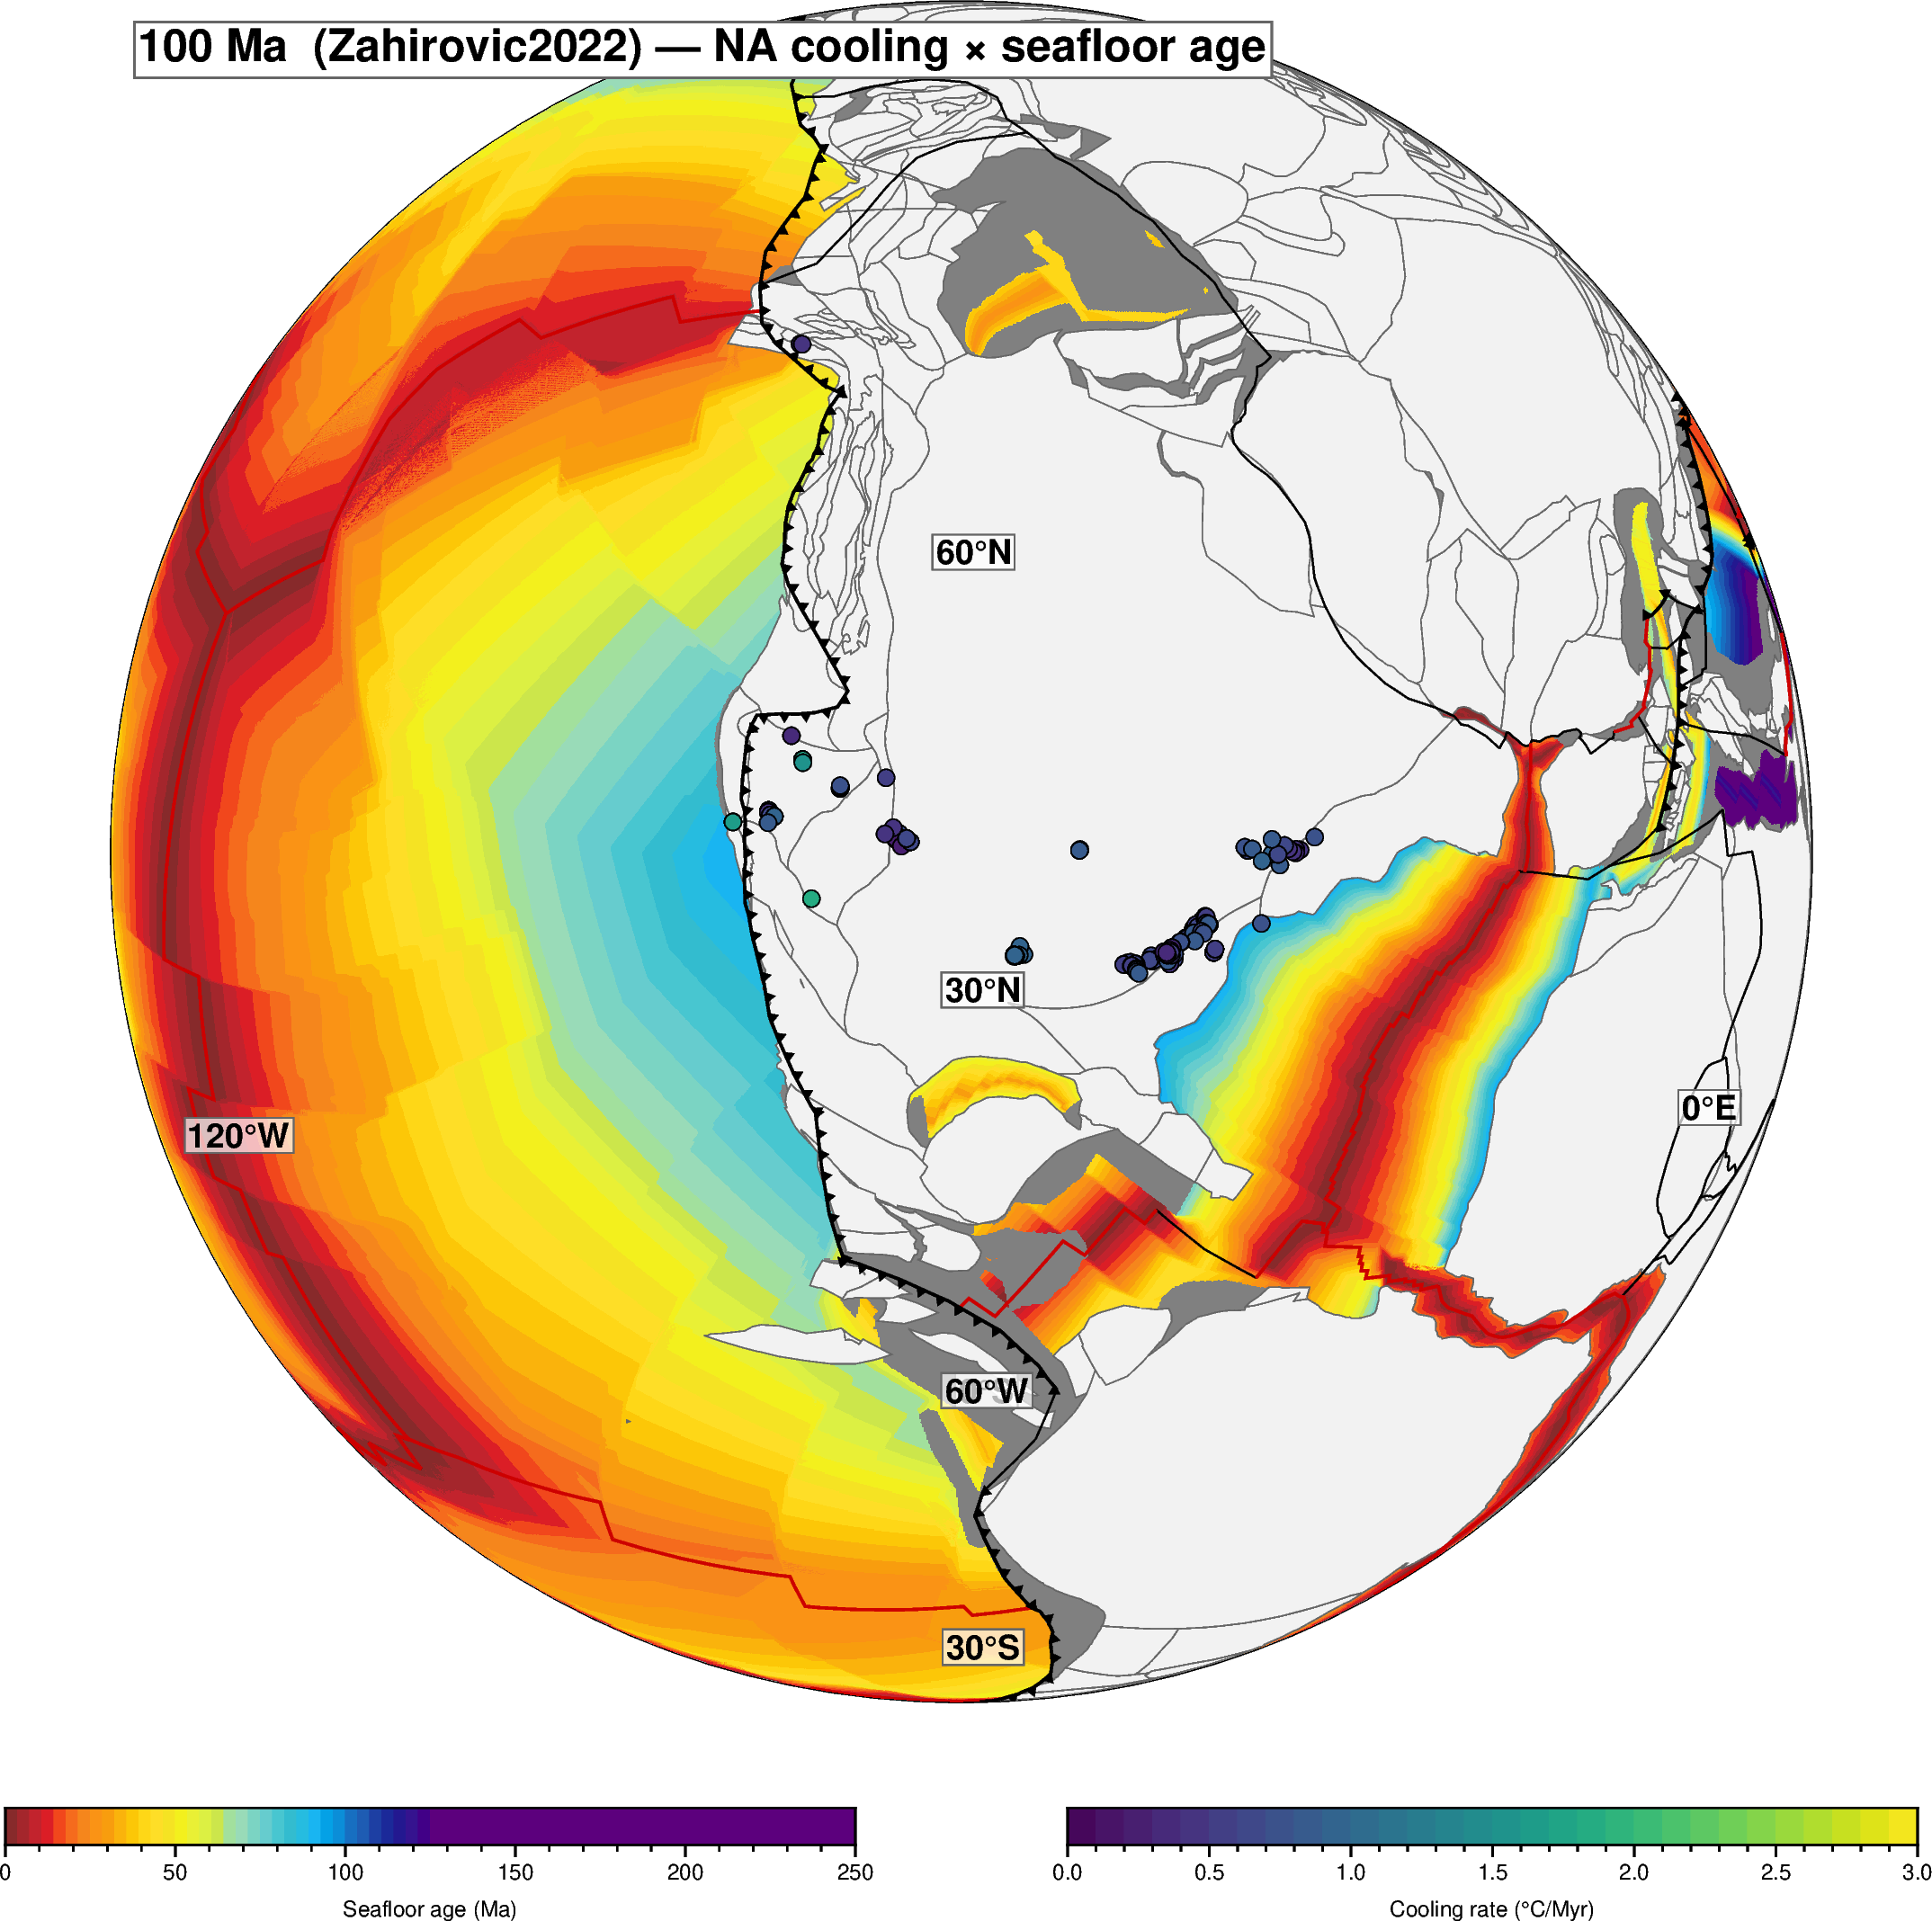

In [5]:
# Z22 age grid (fetched on first run via PMM)
agegrid_da = xr.open_dataarray(
    model.get_raster("AgeGrids", time=float(RECONSTRUCTION_TIME))
)

fig_A = pygmt.Figure()
# Compute NA-centred orthographic projection dynamically. The reference
# point (present-day Kansas, NA_PLATE_ID=101) is reconstructed through
# Z22 to RECONSTRUCTION_TIME using pygplates directly so we get a single
# rotation applied to a known plate-ID (skipping the static-polygon
# assignment step which can silently drop points).
import pygplates as _pgp
_rot_A = recon.rotation_model.get_rotation(
    to_time=float(RECONSTRUCTION_TIME),
    moving_plate_id=NA_PLATE_ID,
    from_time=0.0, anchor_plate_id=ANCHOR_PLATE_ID)
_pt_A = _pgp.PointOnSphere(NA_CENTRE_LAT_PRESENT, NA_CENTRE_LON_PRESENT)
_c_lat, _c_lon = (_rot_A * _pt_A).to_lat_lon()
print(f"  §3 Layer A: NA centre at {RECONSTRUCTION_TIME:.0f} Ma → "
      f"({_c_lon:+.1f}°E, {_c_lat:+.1f}°N)  (was present-day "
      f"({NA_CENTRE_LON_PRESENT:+.0f}°E, {NA_CENTRE_LAT_PRESENT:+.0f}°N))")
_GLOBAL_PROJ = f"G{_c_lon:.2f}/{_c_lat:.2f}/{GLOBE_WIDTH_CM}c"
fig_A.basemap(region="d", projection=_GLOBAL_PROJ,
                frame=["afg", "xa60g60", "ya30g30"])
pygmt.makecpt(cmap="data/age_2020.cpt", series=[0, 250, 1], background="o")
fig_A.grdimage(agegrid_da, cmap=True)
gplot.time = float(RECONSTRUCTION_TIME)
gplot.plot_continents(fig_A, fill="gray95", pen="0.3p,gray40")
gplot.plot_all_topological_sections(fig_A, pen="0.5p,black")    # thin BLACK backbone
gplot.plot_ridges(fig_A, pen="0.8p,red3")
gplot.plot_trenches(fig_A, pen="0.8p,black")
gplot.plot_subduction_teeth(fig_A, color="black")
fig_A.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/1c",
               frame=["xa50f10+lSeafloor age (Ma)"])
# Cooling-rate dots
pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
fig_A.plot(x=samples_now["rlon"], y=samples_now["rlat"],
           fill=samples_now["cooling_rate"], cmap=True,
           style="c0.16c", pen="0.3p,black")
fig_A.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/1c",
               frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])
fig_A.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME}) — NA cooling × seafloor age",
           position="TL", offset="0.25c/-0.25c", justify="TL",
           font="12p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
# Graticule lat/lon labels — drawn LAST so nothing overlays them
annotate_globe_graticule(fig_A, _c_lon, _c_lat, lon_step=60, lat_step=30)
fig_A.show(width=900)

### What this figure shows you

At 100 Ma the North American plate is bracketed by an active Farallon subduction margin to the west (visible as the trench arc with subduction teeth along \~130-100°W), a young Atlantic Ocean opening to the east (with Cretaceous seafloor age visible offshore), and passive Arctic margins to the north. The **Sevier fold-and-thrust belt** was actively building along the western interior at this time, and the **Western Interior Seaway** flooded the mid-continent between the Cordillera and the Appalachian remnants.

If subduction dynamics were driving upper crustal cooling rates, yellow viridis dots — fast-cooling samples — should concentrate along the **western Cordillera and the Sevier hinterland**, tracking the exhumation of the retro-arc mountain belt driven by Farallon flat-slab subduction and thick-skinned Laramide deformation that ramped up from \~80 Ma onward. Cratonic-interior samples (Great Plains, Canadian Shield) show slow cooling — as expected for a stable interior far from the active margin. A lack of such a relationship (as shown here at 100 Ma) may suggest other Earth system processes were governing denudational cooling at that time, or it simply indicates that the time-averaged cooling rates calculated in Section 2 based on cooling rates alone — as necessitated by a lack of available regional thermal history model results — may not be able to resolve more subtle spatio-temporal trends in tectonically-driven upper crustal cooling.


## 4. Layer B — cooling rates × paleotopography (North American regional zoom)

Two Albers-conic panels centred over North America at user-configurable snapshot ages (defaults 100 + 200 Ma — Sevier peak vs earlier Jurassic Cordilleran margin). Geochemistry-corrected Scotese & Wright (2018) paleo-DEM (reused from T59) provides the topographic context — where inherited relief was at each snapshot age. Each panel is self-consistent: cooling rates recomputed at that age, sample lat/lon reconstructed through the SW plate model to that age (respecting the plate-model-match rule), rendered in GMT's `dem2` land-elevation palette (browns → tans → whites for the 0-4500 m land range). Cooling-rate dots are expected to track regions of pre-existing high relief (Sevier fold-and-thrust belt, Laramide arches, Cordilleran interior) where reactivation drives cooling pulses.

Compare the two panels to see how the sampled cooling-rate distribution relates to inherited relief at different points in the Cordilleran orogenic history.


2026-07-21,16:54:01 - pmm - WARNING - The layer(Coastlines) was not found in model(scotese_and_wright2018).


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


  Layer B panel target 100 Ma → SW DEM 100Ma_corrected_SW.nc (100 Ma)
    dem range (p2-p98): -5120 to 1717 m — palette step 150 m
    panel 100 Ma: SW paleo-centre -61.0°E +37.6°N; region [-121.0, -1.0, 7.6, 67.6]


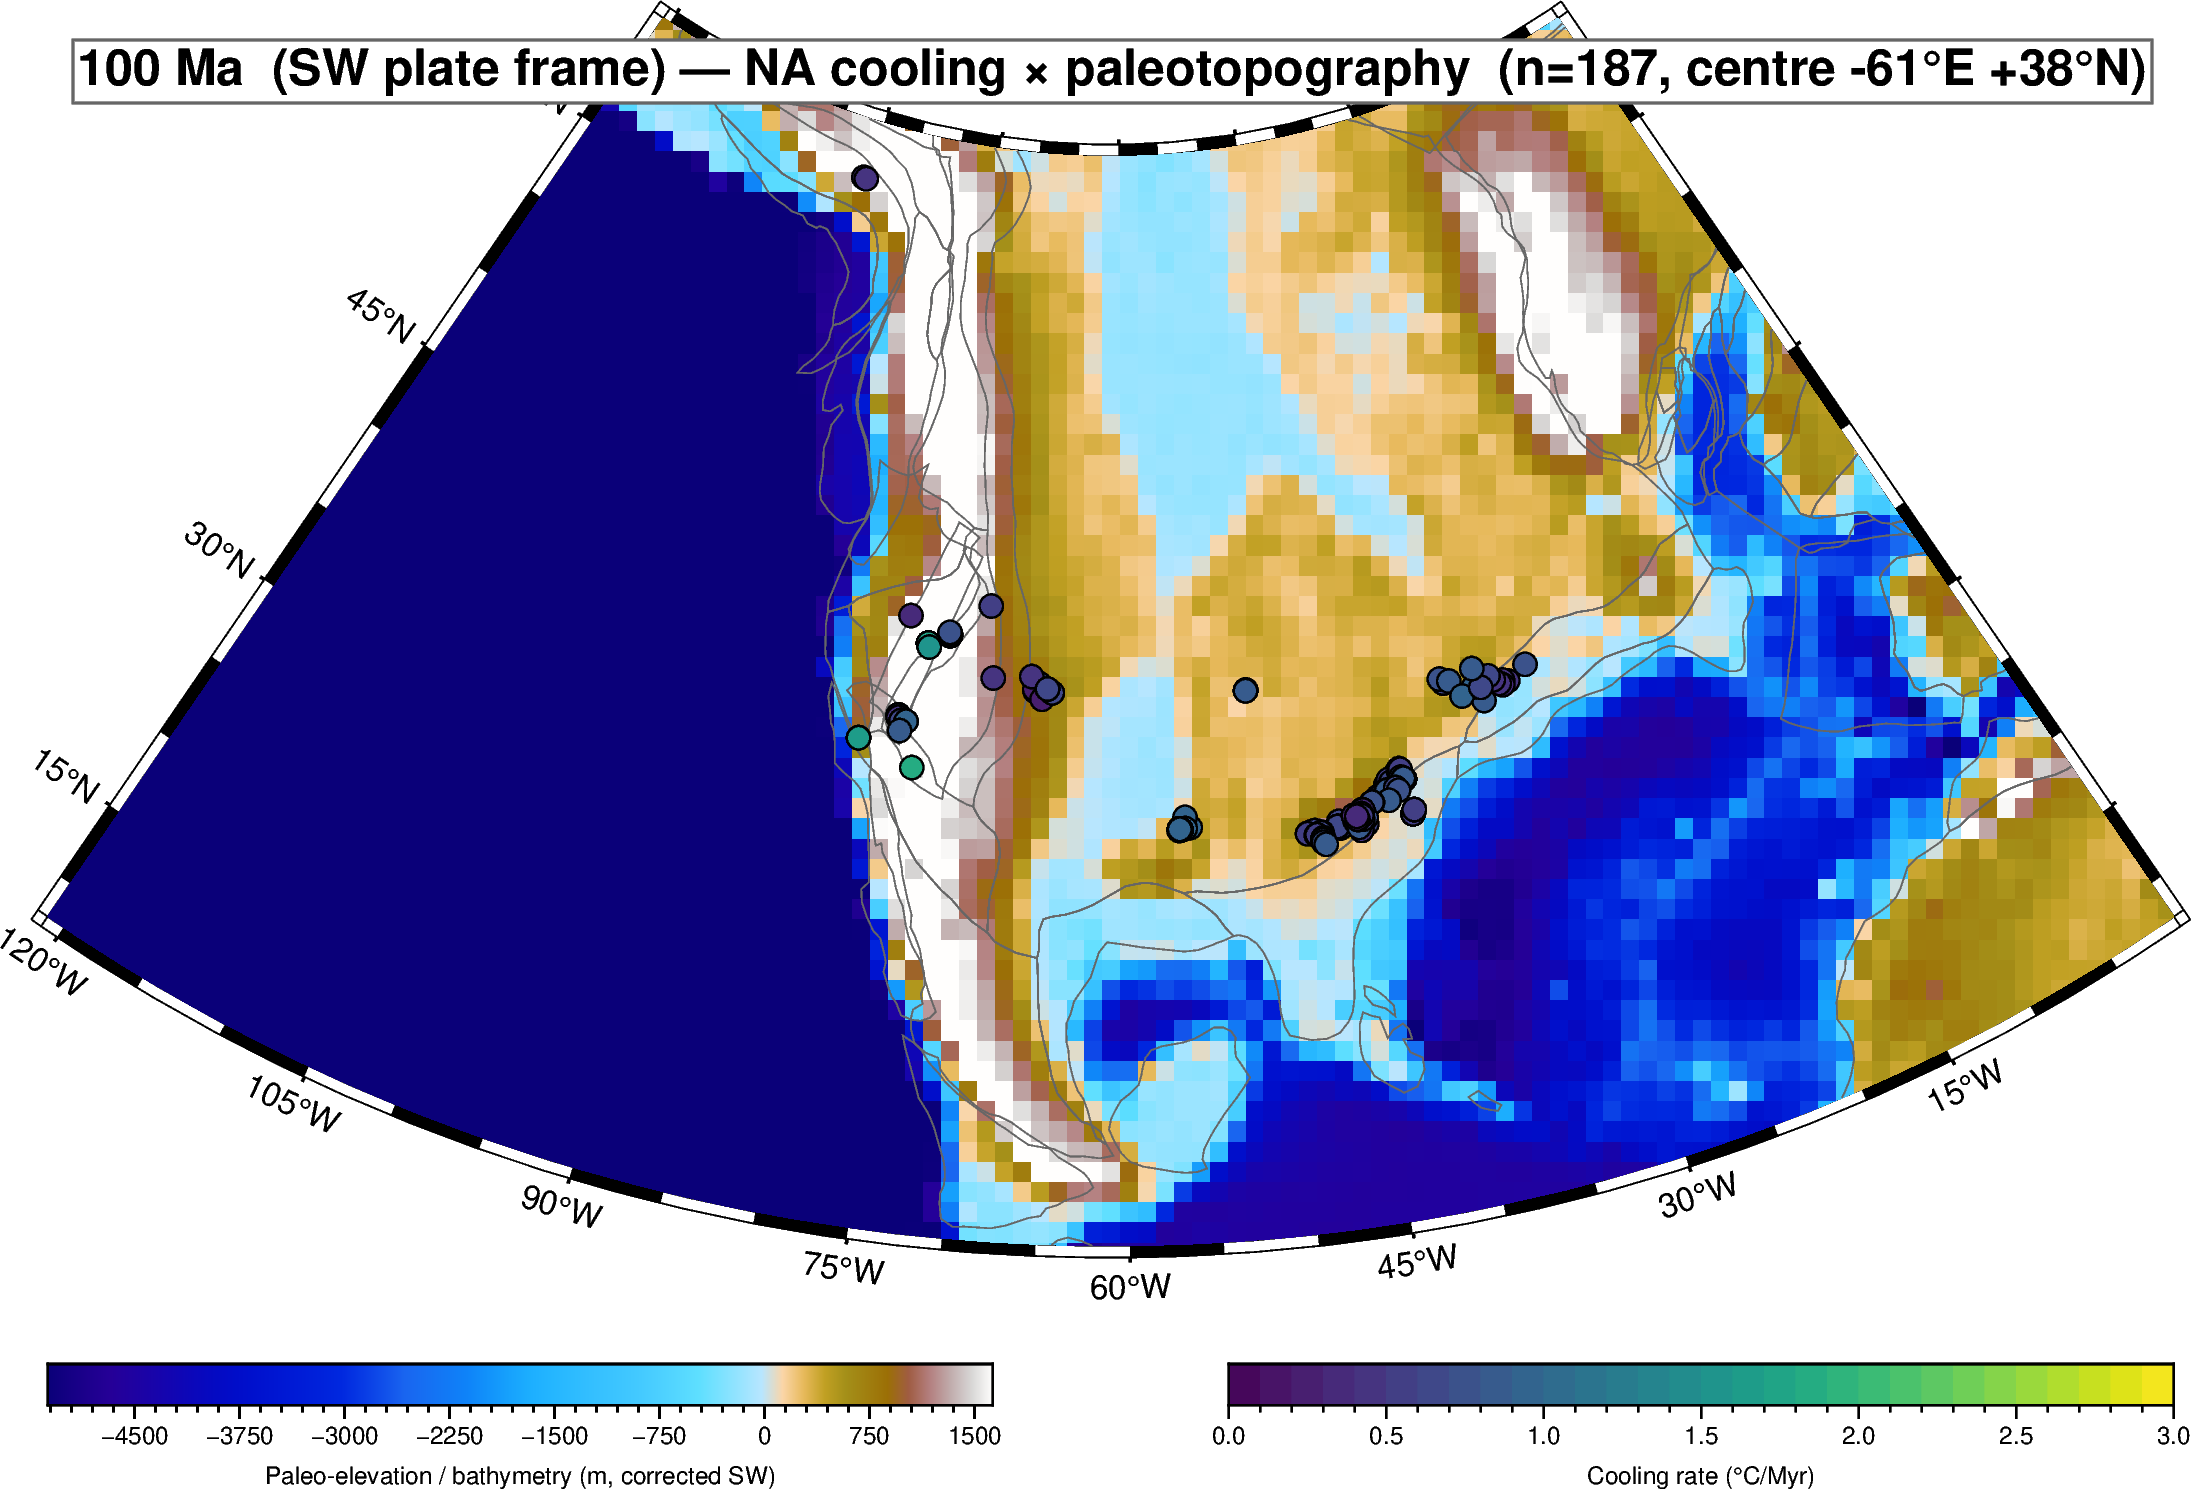

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


  Layer B panel target 200 Ma → SW DEM 200Ma_corrected_SW.nc (200 Ma)
    dem range (p2-p98): -3440 to 1858 m — palette step 150 m
    panel 200 Ma: SW paleo-centre -41.4°E +19.4°N; region [-101.4, 18.6, -10.6, 49.4]


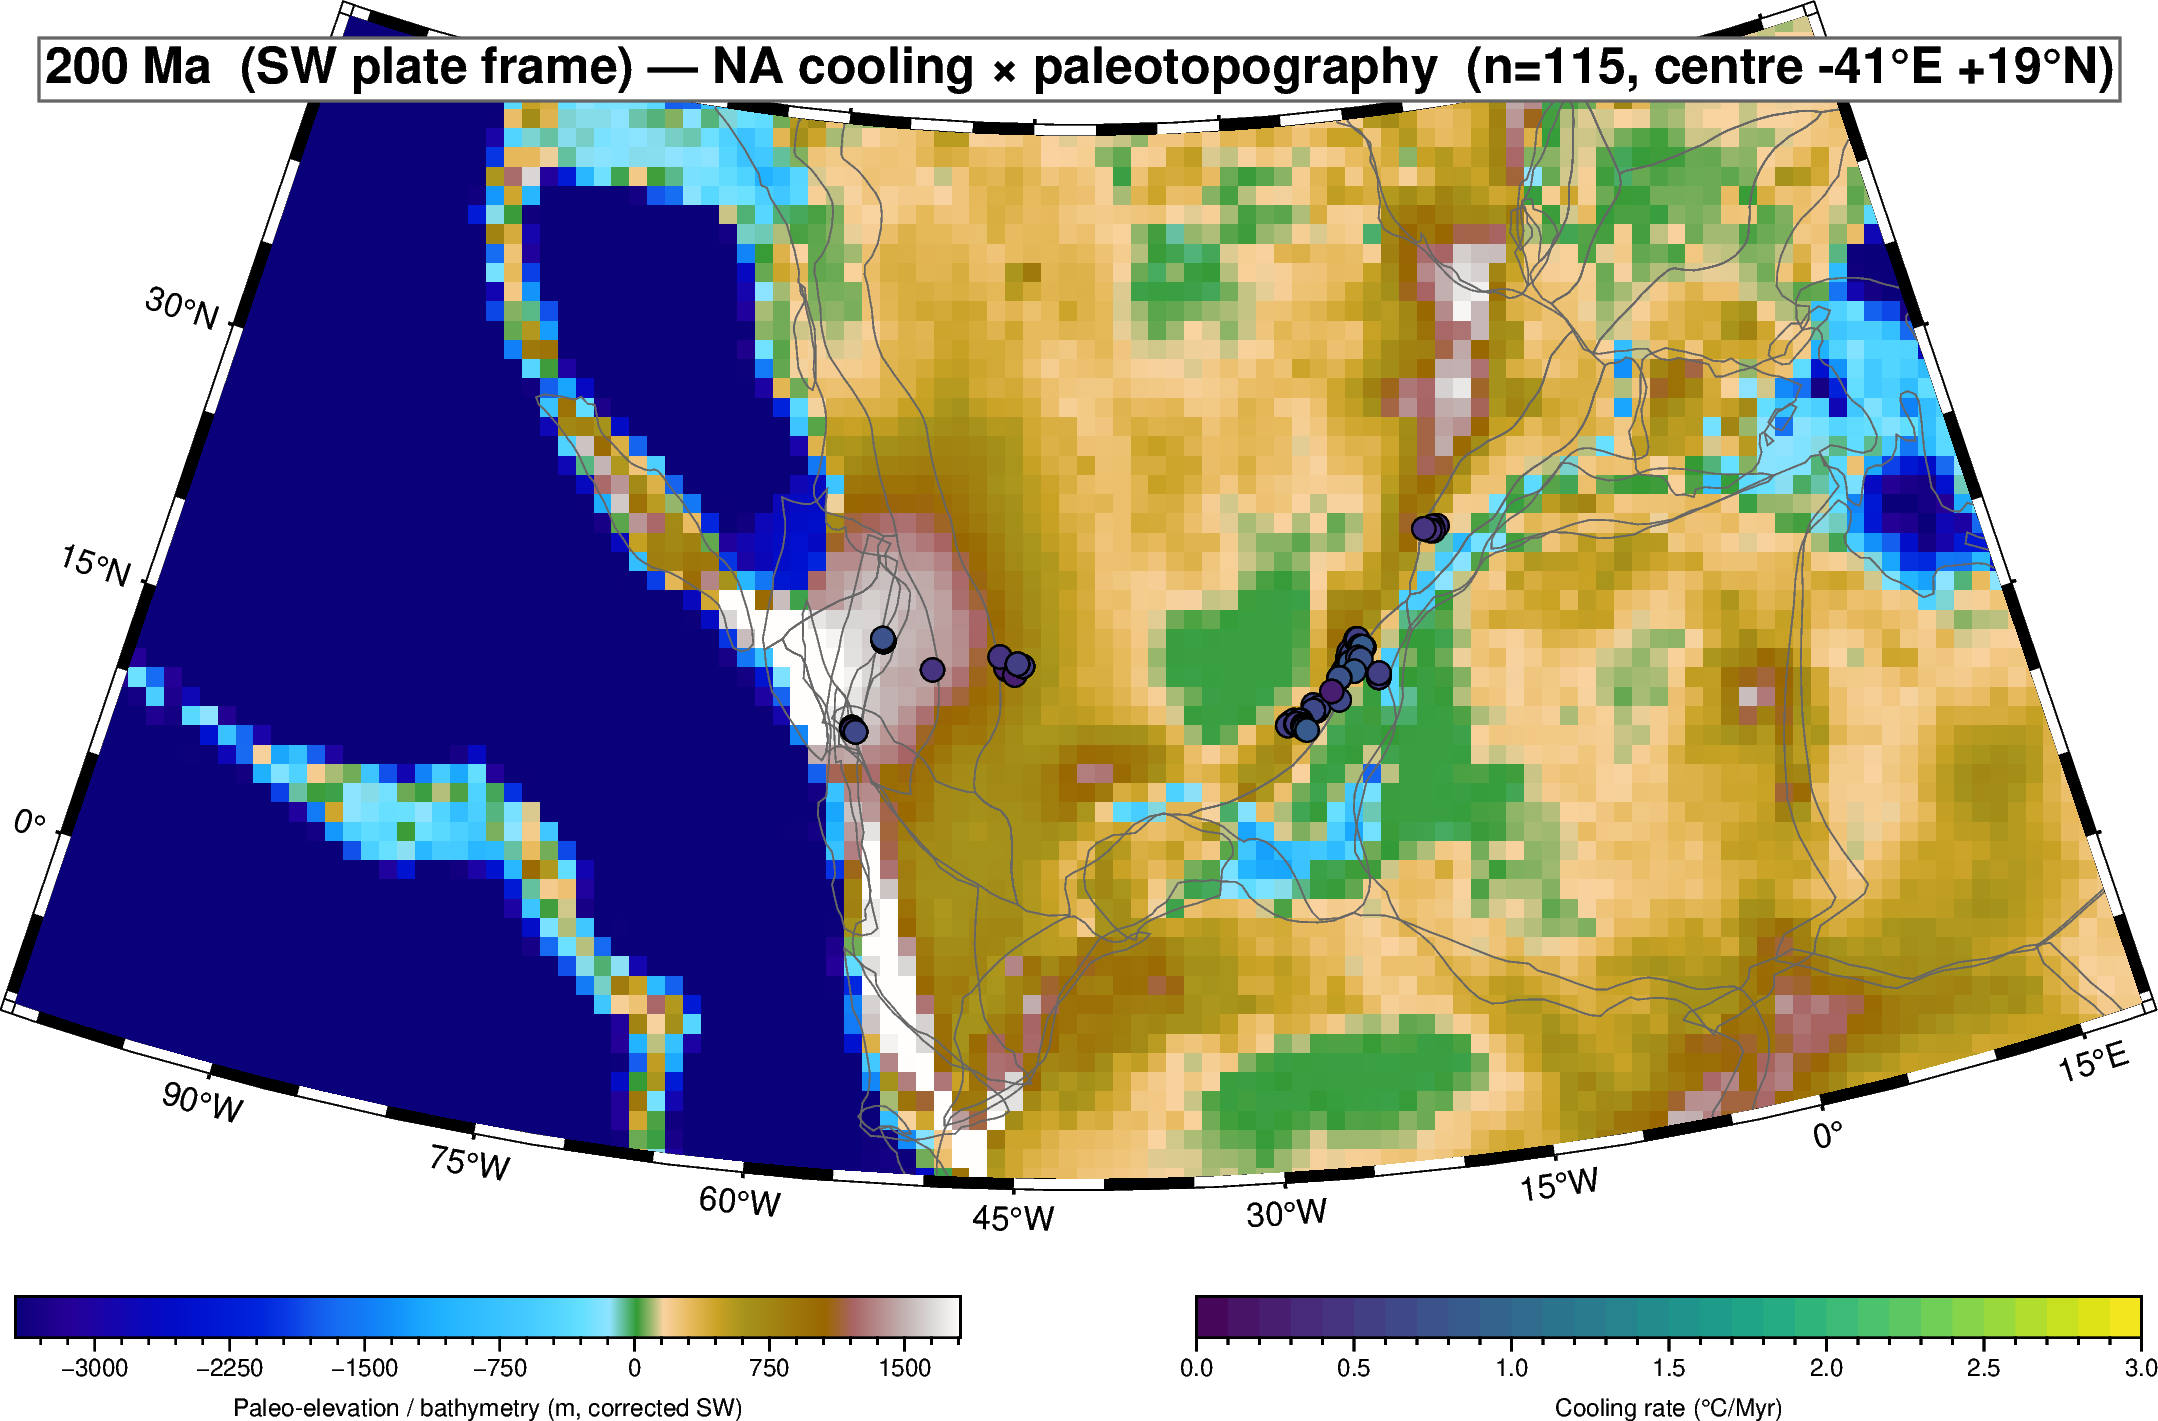

In [6]:
# House-style: one pygmt.Figure() per Layer-B panel, iterating over
# LAYER_B_SNAPSHOT_AGES. Each panel is self-consistent: cooling rate
# recomputed at that age, sample lat/lon reconstructed through the SW
# plate model to that age (plate-model-match rule respected).
import re as _re

paleotopo_steps = sorted(
    int(_re.search(r"^(\d+)Ma_", p.name).group(1))
    for p in PALEODEM_DIR.glob("*Ma_corrected_SW.nc")
)

# Set up the Scotese & Wright reconstruction stack (once, reused per panel)
model_sw = pmm.get_model("scotese_and_wright2018", data_dir="./gplately_data")
recon_sw = gplately.PlateReconstruction(
    rotation_model=model_sw.get_rotation_model(),
    topology_features=model_sw.get_topologies() if hasattr(model_sw, "get_topologies") else None,
    static_polygons=model_sw.get_static_polygons(),
    anchor_plate_id=0,
)
try:
    coastlines_sw = model_sw.get_coastlines()
except Exception:
    coastlines_sw = None

# Per-panel projection centre via SW plate model (respects plate-model-match
# rule — the DEM is in SW plate frame at pt_age, so the projection centre
# must be reconstructed via SW to the same age).
import pygplates as _pgp_sw

def _na_paleo_centre_sw(age_ma: float) -> tuple[float, float]:
    """Return (lon, lat) of the NA reference point reconstructed through
    Scotese-Wright to age_ma."""
    rot = recon_sw.rotation_model.get_rotation(
        to_time=float(age_ma),
        moving_plate_id=NA_PLATE_ID,
        from_time=0.0, anchor_plate_id=0)
    pt = _pgp_sw.PointOnSphere(NA_CENTRE_LAT_PRESENT, NA_CENTRE_LON_PRESENT)
    lat, lon = (rot * pt).to_lat_lon()
    return float(lon), float(lat)

for _target_age in LAYER_B_SNAPSHOT_AGES:
    # Snap to the SW DEM's nearest available age step
    pt_age = min(paleotopo_steps, key=lambda a: abs(a - _target_age))
    pt_path = PALEODEM_DIR / f"{pt_age}Ma_corrected_SW.nc"
    pt_ds = xr.open_dataset(pt_path)
    pt_da = pt_ds["M_corrected"] if "M_corrected" in pt_ds.data_vars else pt_ds["z"]
    print(f"  Layer B panel target {_target_age} Ma → SW DEM {pt_path.name} ({pt_age} Ma)")
    # Cpt range from the actual DEM distribution — p2/p98 clips the extreme
    # tails (deep ocean trenches + rare mountain-peak values) so the main
    # elevation/depth signal fills the palette.
    _pt_vals = pt_da.values[np.isfinite(pt_da.values)]
    _p2  = float(np.nanpercentile(_pt_vals, 2))
    _p98 = float(np.nanpercentile(_pt_vals, 98))
    # Round to a friendly step so the colorbar ticks fall on human numbers.
    _step = max(50.0, round((_p98 - _p2) / 40 / 50) * 50)
    print(f"    dem range (p2-p98): {_p2:.0f} to {_p98:.0f} m — palette step {_step:.0f} m")

    # Recompute cooling rate + per-sample SW reconstruction at pt_age
    samples_sw_base = per_sample_cooling_at(pt_age, hist)
    _sw_rlon, _sw_rlat = [], []
    for _, row in samples_sw_base.iterrows():
        try:
            gp = gplately.Points(recon_sw, [row["lon"]], [row["lat"]], anchor_plate_id=0)
            rl, ra = gp.reconstruct(pt_age, return_array=True, anchor_plate_id=0)
            _sw_rlon.append(float(rl[0]) if len(rl) else np.nan)
            _sw_rlat.append(float(ra[0]) if len(ra) else np.nan)
        except Exception:
            _sw_rlon.append(np.nan); _sw_rlat.append(np.nan)
    samples_sw = samples_sw_base.assign(rlon_sw=_sw_rlon, rlat_sw=_sw_rlat)
    samples_sw = samples_sw.dropna(subset=["rlon_sw", "rlat_sw"]).copy()

    # Paleo-centre of NA at pt_age via SW plate model
    _c_lon_B, _c_lat_B = _na_paleo_centre_sw(pt_age)
    _region_B = [
        _c_lon_B - REGIONAL_HALF_LON_DEG,
        _c_lon_B + REGIONAL_HALF_LON_DEG,
        max(-89.5, _c_lat_B - REGIONAL_HALF_LAT_DEG),
        min( 89.5, _c_lat_B + REGIONAL_HALF_LAT_DEG),
    ]
    _proj_B = (f"B{_c_lon_B:.2f}/{_c_lat_B:.2f}/"
               f"{max(-85.0, _c_lat_B - REGIONAL_SECANT_OFFSET):.2f}/"
               f"{min( 85.0, _c_lat_B + REGIONAL_SECANT_OFFSET):.2f}/"
               f"{REGIONAL_WIDTH_CM}c")
    print(f"    panel {pt_age} Ma: SW paleo-centre {_c_lon_B:+.1f}°E {_c_lat_B:+.1f}°N; "
          f"region {[round(x,1) for x in _region_B]}")

    fig_B = pygmt.Figure()
    fig_B.basemap(region=_region_B, projection=_proj_B, frame=["afg", "xa30g30", "ya15g15"])
    pygmt.makecpt(cmap="etopo1", series=[_p2, _p98, _step], background="o", continuous=True)
    fig_B.grdimage(grid=pt_da, cmap=True, nan_transparent=True)

    gplot_sw = gplately.PlotTopologies(
        plate_reconstruction=recon_sw, coastlines=coastlines_sw,
        continents=model_sw.get_continental_polygons(), COBs=None,
        time=float(pt_age), plot_engine=gplately.PygmtPlotEngine(),
    )
    try:
        fig_B.plot(data=gplot_sw.get_continents(), pen="0.3p,gray40")
    except Exception:
        pass

    # Colorbar ticks — annotate every ~5× the step, minor tick every step.
    _anno = _step * 5
    fig_B.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/1c",
                    frame=[f"xa{_anno:.0f}f{_step:.0f}+lPaleo-elevation / bathymetry (m, corrected SW)"])
    pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
    if not samples_sw.empty:
        fig_B.plot(x=samples_sw["rlon_sw"], y=samples_sw["rlat_sw"],
                    fill=samples_sw["cooling_rate"], cmap=True,
                    style="c0.20c", pen="0.4p,black")
    fig_B.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/1c",
                    frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])
    fig_B.text(text=f"{pt_age} Ma  (SW plate frame) — NA cooling × paleotopography  (n={len(samples_sw)}, centre {_c_lon_B:+.0f}°E {_c_lat_B:+.0f}°N)",
                position="TL", offset="0.25c/-0.25c", justify="TL",
                font="12p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
    fig_B.show(width=900)

### What this figure shows you

Layer B is rendered at the SW PaleoDEM's nearest cadence step to the configured snapshot age. The whole panel — sample cooling-rate snapshot, sample reconstruction, and DEM — sits in `scotese_and_wright2018`'s plate frame at that age (no Z22 quantities appear, respecting the plate-model-match rule).

What you see: the corrected Scotese & Wright paleo-DEM shows the inherited North American relief — the **Sevier fold-and-thrust belt** on the western side of the continent, remnants of the **Appalachian topography** on the east, and the low-relief cratonic interior in between. The fastest-cooling samples (bright viridis) should be located along the **flanks of the Sevier hinterland** and any earlier Laramide arches beginning to emerge — consistent with retro-arc exhumation of the Cordilleran mountain belt.

## 5. Cooling rates × dynamic-topography uplift rate — the Farallon-slab signal

For North America, **dynamic topography is a first-order driver** of Mesozoic-Cenozoic uplift, and Young et al. (2022) `gld428` — which explicitly captures subduction-coupled long-wavelength mantle flow — is the right substrate to test that hypothesis. Multiple independent lines of evidence link the shallow Farallon flat slab, its subsequent detachment (\~40-25 Ma), and the associated mantle upwelling to the observed uplift signatures across the Colorado Plateau, the southern Rocky Mountains, and the western Great Plains (Moucha et al. 2008; Forte et al. 2010; Karlstrom et al. 2012; Liu et al. 2011).

The dominant post-100 Ma North American uplift driver — Farallon flat-slab subduction and its detachment — is exactly the class of subduction-coupled dynamic topography that `gld428` is designed to capture. The one North American plume signal `gld428` does not represent is the post-16 Ma Yellowstone-hotspot track, and this affects only a small subset of the sample compilation.

We use the **plate-frame** `gld428` grids at 5-Myr cadence (0-250 Ma coverage) and compute the DT uplift rate as

$$\dot{z}_{\text{dyntopo}}(t) = \frac{DT_{\text{plate}}(t) - DT_{\text{plate}}(t + 5\,\text{Myr})}{5\,\text{Myr}}\quad [\text{m/Myr}]$$

Positive values indicate the mantle was lifting the surface over the preceding 5 Myr; negative values indicate dynamic subsidence. **The differencing is done in the plate frame** — where a point on the plate has a fixed (lat, lon) regardless of time — and the resulting Δz field is then rotated to the M21 NNR mantle frame at age `t` for paleo-geographic display. Differencing mantle-frame grids conflates true mantle uplift with the plate-motion-through-DT-field signal (the same lat/lon corresponds to different plate-points at different times) and is not physically meaningful.

### Coverage and caveats

- The 5-Myr-cadence `gld428` grids used here are **not bundled with the tutorial suite** (\~150 MB across 51 NetCDFs). Canonical download source: <https://www.earthbyte.org/webdav/ftp/Dynamic_Topography/gld428_m21/> (EarthByte webdav; a Zenodo mirror will be added on final release). Download the 5-Myr-cadence subset into `data/Young2022_dynamic_topo/plate_frame/5my_0-250Ma/`, then re-run this cell.
- The 5-Myr subset covers **0-250 Ma**, exactly the useful window for the North American Farallon-slab story: Cordilleran-orogen inception in the Jurassic (\~200 Ma), Sevier fold-and-thrust peak in the mid-Cretaceous (\~100 Ma), Laramide flat-slab phase (\~80-40 Ma), post-detachment mantle re-influx and uplift (\~40-25 Ma). The default `MAX_SAMPLE_AGE_MA = 200` restricts the analysis to this window with 50 Myr of gld428 headroom for Δz differencing.
- `gld428` suppresses thermal plumes by design — any plume-driven uplift is not represented. For North America this affects (at most) the Yellowstone track post-16 Ma, a small subset of samples.
- For deeper-time exploration (Paleozoic-Neoproterozoic cratonic samples), swap to the 20-Myr cadence 0-980 Ma subset — see the *Extend this* section at the bottom of the notebook for the config swap.


In [ ]:
# === USER CONFIGURATION — §5/§6/§7 (dyntopo additions) ==================
# Snapshot ages for the multi-figure block. Four ages spanning the useful
# Farallon-slab window (Jurassic Cordilleran onset → Sevier peak → late
# Laramide → post-detachment): 50, 100, 150, 200 Ma. Adjust to zoom into
# a specific epoch.
DYNTOPO_SNAPSHOT_AGES = [50, 100, 150, 200]
# Step (Myr) for the uplift-rate difference. Must match the gld428
# 5-Myr-cadence subset used here (0-250 Ma).
DYNTOPO_STEP_MYR      = 5
# ±50 m/Myr cpt range for the uplift-rate basemap (matches T37).
UPLIFT_RANGE_M_PER_MYR = (-50, 50, 2)

# Plate model for sample reconstruction in §5/§6/§7. Young et al. (2022)
# ran gld428 in the M21 NNR (Merdith 2021 no-net-rotation) frame — so per
# the plate-model-match rule we set up a separate stack here. The Z22
# stack used in §1-§4 stays untouched.
M21NNR_DIR            = Path(os.environ.get("ZENODO_YOUNG2022_DIR", "zenodo_data/dynamic_topography_Young2022")) / "plate_model"

# Young 2022 gld428 PLATE-FRAME 5-Myr cadence grids. Filename pattern:
# "<age>.00.nc" (e.g. 0.00.nc, 5.00.nc, ..., 250.00.nc). Skip
# Masked_<age>.00.nc variants — they are ocean-masked siblings and
# would break a naïve glob that expects XX.XX.nc only.
GLD428_DIR = Path(os.environ.get("ZENODO_YOUNG2022_DIR", "zenodo_data/dynamic_topography_Young2022")) / "plate_frame/5my_0-250Ma"
_gld_ncs = ([p for p in GLD428_DIR.glob("*.nc")
             if not p.name.startswith("Masked_")]
            if GLD428_DIR.exists() else [])
if not _gld_ncs:
    raise FileNotFoundError(
        f"gld428 5-Myr grids not found at {GLD428_DIR}. "
        "Download the suite's Zenodo data archive and extract it as zenodo_data/ "
        "at the repo root (sibling of Notebooks/ and data/), or set the "
        "ZENODO_YOUNG2022_DIR env var to point at an existing copy. "
        f"See §1 Data availability for the full recipe."
    )
print(f"  gld428 PLATE-frame dir: {GLD428_DIR}")
print(f"    NCs available (excluding Masked_): {len(_gld_ncs)}")
print(f"  M21 NNR plate-model dir: {M21NNR_DIR}")

# === M21 NNR PlateReconstruction (separate from the Z22 stack in §1-§4) ===
import pygplates as _pgp
m21_rot_files  = sorted(M21NNR_DIR.glob("*.rot"))
m21_all_gpml   = sorted(M21NNR_DIR.glob("*.gpml"))
m21_topo_files = [f for f in m21_all_gpml
                  if "shapes_continents" not in f.name
                  and "shapes_cratons"   not in f.name]
m21_continents_fc = _pgp.FeatureCollection(str(M21NNR_DIR / "shapes_continents_Merdith_et_al.gpml"))
recon_m21 = gplately.PlateReconstruction(
    rotation_model=_pgp.RotationModel([str(p) for p in m21_rot_files]),
    topology_features=[_pgp.FeatureCollection(str(f)) for f in m21_topo_files],
    static_polygons=m21_continents_fc,
    anchor_plate_id=0,
)


# ---- gld428 plate-frame Δz helper ----------------------------------------
def _gld428_path(age_ma: float) -> Path:
    """Return the path to the gld428 5-Myr-cadence grid at the nearest
    5-Myr step. Filename convention: "<age>.00.nc" (e.g. 0.00.nc,
    5.00.nc, ..., 250.00.nc). Masked_ variants are ocean-masked
    siblings and are ignored."""
    a = int(round(age_ma / DYNTOPO_STEP_MYR) * DYNTOPO_STEP_MYR)
    return GLD428_DIR / f"{a}.00.nc"


def uplift_rate_for_display(age_ma: float) -> xr.DataArray:
    """Plate-frame Δz (m/Myr) rotated to the M21 NNR mantle frame at age_ma.
    Uses gld428 grids at age_ma and age_ma + DYNTOPO_STEP_MYR."""
    p0 = _gld428_path(age_ma)
    p1 = _gld428_path(age_ma + DYNTOPO_STEP_MYR)
    if not p0.exists() or not p1.exists():
        raise FileNotFoundError(f"missing gld428 pair: {p0.name} / {p1.name}")
    ds0 = xr.open_dataset(p0); ds1 = xr.open_dataset(p1)
    z0 = ds0["z"]; z1 = ds1["z"]
    dz_pf = (z0 - z1) / float(DYNTOPO_STEP_MYR)   # m/Myr, plate frame
    # Rotate plate-frame Δz to M21 NNR mantle frame at age_ma via
    # gplately.Raster.reconstruct() (T37 helper pattern).
    lon = dz_pf.lon.values; lat = dz_pf.lat.values
    r = gplately.Raster(data=dz_pf.values.astype(np.float32),
                        plate_reconstruction=recon_m21, time=0,
                        extent=[lon.min(), lon.max(), lat.min(), lat.max()])
    rr = r.reconstruct(time=float(age_ma), threads=1,
                       anchor_plate_id=0, inplace=False)
    return xr.DataArray(np.asarray(rr.data), dims=("lat", "lon"),
                        coords={"lat": lat, "lon": lon}, name="uplift_rate")


# ---- sample side: reconstruct through M21 NNR + sample gld428 at present-day
# lat/lon (plate-frame is fixed to the plate, so present-day lat/lon is the
# right sampling location — see T75 build_master convention) ------
def sample_dyntopo_at_age(age_ma: float, hist_df: pd.DataFrame) -> pd.DataFrame:
    """Per-sample cooling rate + gld428 dyntopo uplift rate at age_ma."""
    samp = per_sample_cooling_at(age_ma, hist_df)
    if samp.empty:
        return samp.assign(rlon_m21=[], rlat_m21=[], uplift_rate_m_per_Myr=[])
    # Per-sample M21 NNR reconstruction — batch gplately.Points.reconstruct
    # silently drops unreconstructable rows (gplately API gotcha), so loop and
    # preserve NaN placeholders to keep the row count aligned with samp.
    _rlon, _rlat = [], []
    for _, row in samp.iterrows():
        try:
            gp = gplately.Points(recon_m21, [row["lon"]], [row["lat"]],
                                  anchor_plate_id=0)
            rl, ra = gp.reconstruct(age_ma, return_array=True, anchor_plate_id=0)
            _rlon.append(float(rl[0]) if len(rl) else np.nan)
            _rlat.append(float(ra[0]) if len(ra) else np.nan)
        except Exception:
            _rlon.append(np.nan); _rlat.append(np.nan)
    samp = samp.assign(rlon_m21=_rlon, rlat_m21=_rlat)
    # Sample plate-frame gld428 uplift rate at each sample's PRESENT-DAY
    # lat/lon (plate frame is rigidly attached to the plate → present-day
    # coord is the right lookup)
    try:
        upl_pf = uplift_rate_for_display(float(age_ma))
        vals = upl_pf.interp(lon=xr.DataArray(samp["lon"].values, dims="s"),
                              lat=xr.DataArray(samp["lat"].values, dims="s"),
                              method="linear").values
        samp["uplift_rate_m_per_Myr"] = vals
    except FileNotFoundError:
        samp["uplift_rate_m_per_Myr"] = np.nan
    return samp

print("  ✓ gld428 + M21 NNR helpers set up")


### How to read the dyntopo basemap

The polar (red-blue) cpt is centred at **zero uplift rate**: red = surface lifted by mantle flow over the preceding 20 Myr (broad mantle upwelling underneath), blue = surface subsided (mantle downwelling, typically slab-pull from a nearby subduction zone). ±50 m/Myr saturates the strongest features. NA cooling-rate dots overlay this, coloured by per-sample rate.

For North America the signal we're chasing is the **long-wavelength Farallon-slab dynamic topography**:

- The Cordilleran margin should show **subsidence** (blue) during flat-slab periods (\~90-40 Ma), as the shallowly-underthrust slab drags the base of the continental lithosphere downward.
- Following slab detachment (\~40-25 Ma) and mantle re-influx into the vacated space, the western interior should transition to **uplift** (red), producing the widely-recognised Cenozoic exhumation phase across the Colorado Plateau + southern Rockies.
- The cratonic interior (Great Plains, Canadian Shield) should show subtle DT modulation, mostly slow.

If NA cooling rates correlate positively with `gld428` uplift rate through the Cretaceous-Cenozoic, that's direct evidence that the dominant driver of NA exhumation is mantle-flow uplift — i.e., the Farallon story.


## 6. Cooling samples on gld428 uplift-rate globes — through the Farallon window

Four orthographic globes centred on North America, one per snapshot age in `DYNTOPO_SNAPSHOT_AGES` (defaults 50, 100, 150, 200 Ma). Together they walk through the Cordilleran orogenic history: Jurassic Cordilleran onset (200 Ma), Sevier fold-and-thrust peak with early Laramide onset (100 Ma), post-Laramide uplift (50 Ma). The Farallon-slab-linked subsidence-then-uplift transition should be visible as the pattern evolves. Each globe is one `pygmt.Figure()` — `pygmt.subplot` allocates uniform cell dimensions and inherits GMT's same-projection-family assumption, which breaks far-hemisphere clipping on orthographic panels.

In [ ]:
# House style: one pygmt.Figure() per orthographic
# panel. pygmt.subplot allocates uniform cells and inherits GMT's
# same-projection-family assumption; when panels use orthographic (G...)
# the outer canvas doesn't clip the far-hemisphere correctly, leading
# to raster pixels rendered outside the globe. One Figure per panel
# avoids the whole class of bug.

DYNTOPO_PROJ_W = 12    # cm width per globe

import pygplates as _pgp

def _na_paleo_centre_m21(age_ma: float) -> tuple[float, float]:
    """Return (lon, lat) of the NA reference point (present-day Kansas,
    plate 101) reconstructed through M21 NNR to age_ma. Used to
    dynamically centre the §6 orthographic globes on NA at each age."""
    rot = recon_m21.rotation_model.get_rotation(
        to_time=float(age_ma),
        moving_plate_id=NA_PLATE_ID,
        from_time=0.0, anchor_plate_id=0)
    pt = _pgp.PointOnSphere(NA_CENTRE_LAT_PRESENT, NA_CENTRE_LON_PRESENT)
    lat, lon = (rot * pt).to_lat_lon()
    return float(lon), float(lat)

for age in DYNTOPO_SNAPSHOT_AGES:
    try:
        upl_rate = uplift_rate_for_display(float(age))
    except FileNotFoundError as e:
        print(f"  ⚠ {age} Ma: {e}")
        continue
    upl_rate.gmt.registration = 0
    upl_rate.gmt.gtype        = 1

    fig_age = pygmt.Figure()
    _c_lon, _c_lat = _na_paleo_centre_m21(age)
    _proj = f"G{_c_lon:.2f}/{_c_lat:.2f}/{DYNTOPO_PROJ_W}c"
    fig_age.basemap(region="d", projection=_proj,
                     frame=["afg", "xa60g60", "ya30g30"])

    # Uplift-rate raster
    pygmt.makecpt(cmap="vik", series=list(UPLIFT_RANGE_M_PER_MYR),
                   continuous=True, background="o")
    fig_age.grdimage(grid=upl_rate, cmap=True, nan_transparent=True)

    # M21 NNR continental outlines at this age
    gplot_m = gplately.PlotTopologies(
        plate_reconstruction=recon_m21,
        coastlines=None, continents=m21_continents_fc, COBs=None,
        time=float(age), plot_engine=gplately.PygmtPlotEngine())
    try:
        fig_age.plot(data=gplot_m.get_continents(), pen="0.4p,gray20")
    except Exception:
        pass

    # Samples reconstructed via M21 NNR + coloured by cooling rate
    samp = sample_dyntopo_at_age(float(age), hist)
    samp_plot = samp.dropna(subset=["rlon_m21", "rlat_m21"]) if not samp.empty else samp
    if not samp_plot.empty:
        pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1],
                       background="o")
        fig_age.plot(x=samp_plot["rlon_m21"], y=samp_plot["rlat_m21"],
                      fill=samp_plot["cooling_rate"], cmap=True,
                      style="c0.18c", pen="0.3p,black")

    # In-frame age stamp (suite convention)
    fig_age.text(text=f"{int(age)} Ma  (M21 NNR) — NA cooling × gld428 uplift  "
                       f"(n={len(samp)}, centre {_c_lon:+.0f}°E {_c_lat:+.0f}°N)",
                  position="TL", offset="0.25c/-0.25c", justify="TL",
                  font="12p,Helvetica-Bold,black",
                  fill="white", pen="0.6p,gray40")

    # Bottom colour bars per figure
    pygmt.makecpt(cmap="vik", series=list(UPLIFT_RANGE_M_PER_MYR),
                   continuous=True, background="o")
    fig_age.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o-5c/1.0c",
                      frame=["xa20f5+lgld428 uplift rate (m/Myr)"])
    pygmt.makecpt(cmap="viridis", series=[*COOLING_CPT_RANGE, 0.1], background="o")
    fig_age.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o5c/1.0c",
                      frame=["xa0.5f0.1+lCooling rate (@.C/Myr)"])

    # Graticule lat/lon labels — drawn LAST so raster + samples + colorbars
    # do not overlay them
    annotate_globe_graticule(fig_age, _c_lon, _c_lat, lon_step=60, lat_step=30)
    fig_age.show(width=800)

### What these globes tell you

The four panels (50, 100, 150, 200 Ma) trace the long-wavelength dynamic-topography uplift rate at North American sample positions through the Cordilleran orogeny. Because `gld428` explicitly captures subduction-coupled DT (§5), the North American signal we care about is **directly represented** in these maps:

- **50 Ma (Eocene)**: end of the Laramide flat-slab phase — slab detachment is imminent (\~40 Ma); expect broad DT patterns beginning to shift from the Cordilleran-interior subsidence regime of the Late Cretaceous to the Cenozoic post-detachment mantle re-influx signal.
- **100 Ma (Cenomanian)**: mid-Cretaceous Farallon subduction has been ongoing for \~100 Myr; expect subsidence bands aligned with the active margin and moderate mantle-return-flow uplift patches over the continental interior. Sevier fold-and-thrust belt is at its peak building height.
- **150 Ma (Kimmeridgian)**: Late Jurassic Cordilleran orogen in its building phase; Farallon subduction well-established.
- **200 Ma (Early Jurassic)**: near the onset of Farallon-family subduction (Cordilleran-orogen inception); Pangea break-up barely under way, DT signal dominated by mantle warming under the still-thick supercontinent.

Compare the North American cooling-rate dots overlaid on each panel against these DT signatures. Persistent visual co-location of the fastest-cooling samples (yellow viridis) with red (uplift) patches would be evidence for the DT-driven-exhumation hypothesis; persistent co-location with blue (subsidence) patches or no consistent pattern would argue for competing drivers (climate, tectonic uplift decoupled from mantle flow, or DT signal not resolved at this cadence).


## 7. Cross-variable correlations — cooling rate vs DT uplift rate, time-series

Same pipeline as the earlier convergence-rate analysis, but with `gld428` uplift rate replacing the convergence rate. For each age slice with at least three NA samples actively cooling, we sample `gld428` at the M21 NNR-reconstructed sample positions and compute Pearson `r(cooling, uplift_rate)`. A positive trend across many ages would support the plume-driven-exhumation hypothesis.

In [9]:
# Build per-age master tables (cooling rate + dyntopo uplift rate at M21 NNR pos)
DYNTOPO_MASTER_DIR = ZENODO_THERMOCHRON_NA_DIR / "dyntopo_master"
DYNTOPO_MASTER_DIR.mkdir(parents=True, exist_ok=True)

def dyntopo_master_path(age): return DYNTOPO_MASTER_DIR / f"dyntopo_master_{int(age):03d}Ma.parquet"

# Build for ages within gld428 coverage
DYNTOPO_AGES      = [a for a in AGES_MA if a + DYNTOPO_STEP_MYR <= 250]
# Age list for cooling-vs-uplift Pearson r sweep — use the same set here
# (no plume-suppression restriction is required for NA-Farallon; §5 argues
# gld428 captures the relevant subduction-coupled DT).
DYNTOPO_AGES_CORR = list(DYNTOPO_AGES)
n_built = n_cached = n_skipped = 0
for age in DYNTOPO_AGES:
    p = dyntopo_master_path(age)
    if p.exists(): n_cached += 1; continue
    try:
        df = sample_dyntopo_at_age(float(age), hist)
        if df is None or df.empty: n_skipped += 1; continue
        df["age_Ma"] = float(age)
        df.to_parquet(p); n_built += 1
    except FileNotFoundError:
        n_skipped += 1
print(f"  ✓ built {n_built} new parquet(s); {n_cached} cached; {n_skipped} skipped (no data)")

  ✓ built 0 new parquet(s); 12 cached; 1 skipped (no data)


### Time-series of cooling rate AND dyntopo uplift rate — W vs E NA samples

Two stacked panels spanning the age range set by `AGES_MA`:

- **Top — cooling rate**: derived directly from USGS Geochron thermochronology and unaffected by any `gld428` model limitations.
- **Bottom — `gld428` uplift rate**: sampled at each sample's present-day position (plate-frame attached).

The samples split roughly at the Rocky Mountain front (~-100°E, aligning with the transition from Cordilleran deformation to cratonic interior):

- **Western sector (lon ≤ -100°E)** — Cordillera, Basin & Range, Colorado Plateau, Sierras, Cascades, Coast Ranges
- **Eastern sector (lon > -100°E)** — Great Plains, Midcontinent, Appalachians, Canadian Shield east of ~-100°E

Median ± inter-quartile-range bands per sector; faint background traces are individual sample trajectories. The Farallon story predicts the western sector should show high cooling rates + positive uplift rate in the Late-Cretaceous-to-Cenozoic window; the eastern sector should show slower cooling + weaker DT modulation.

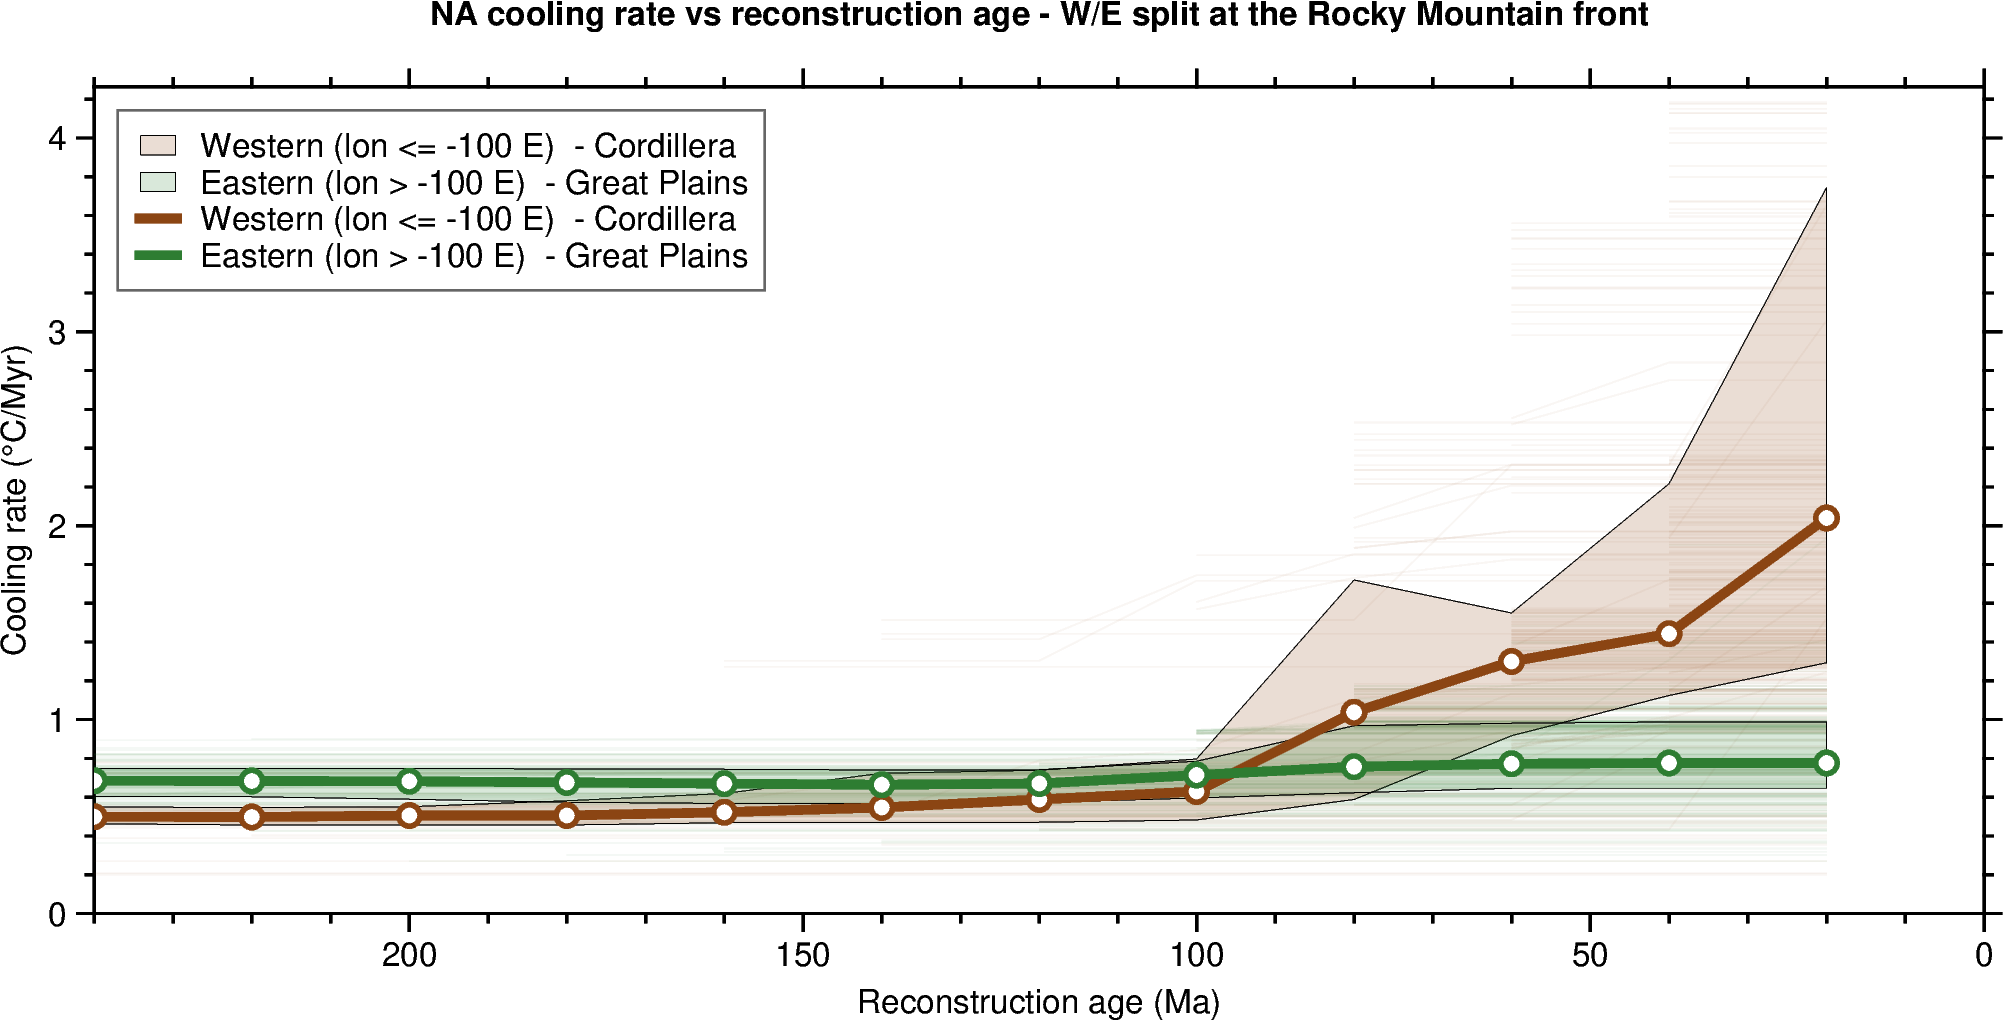

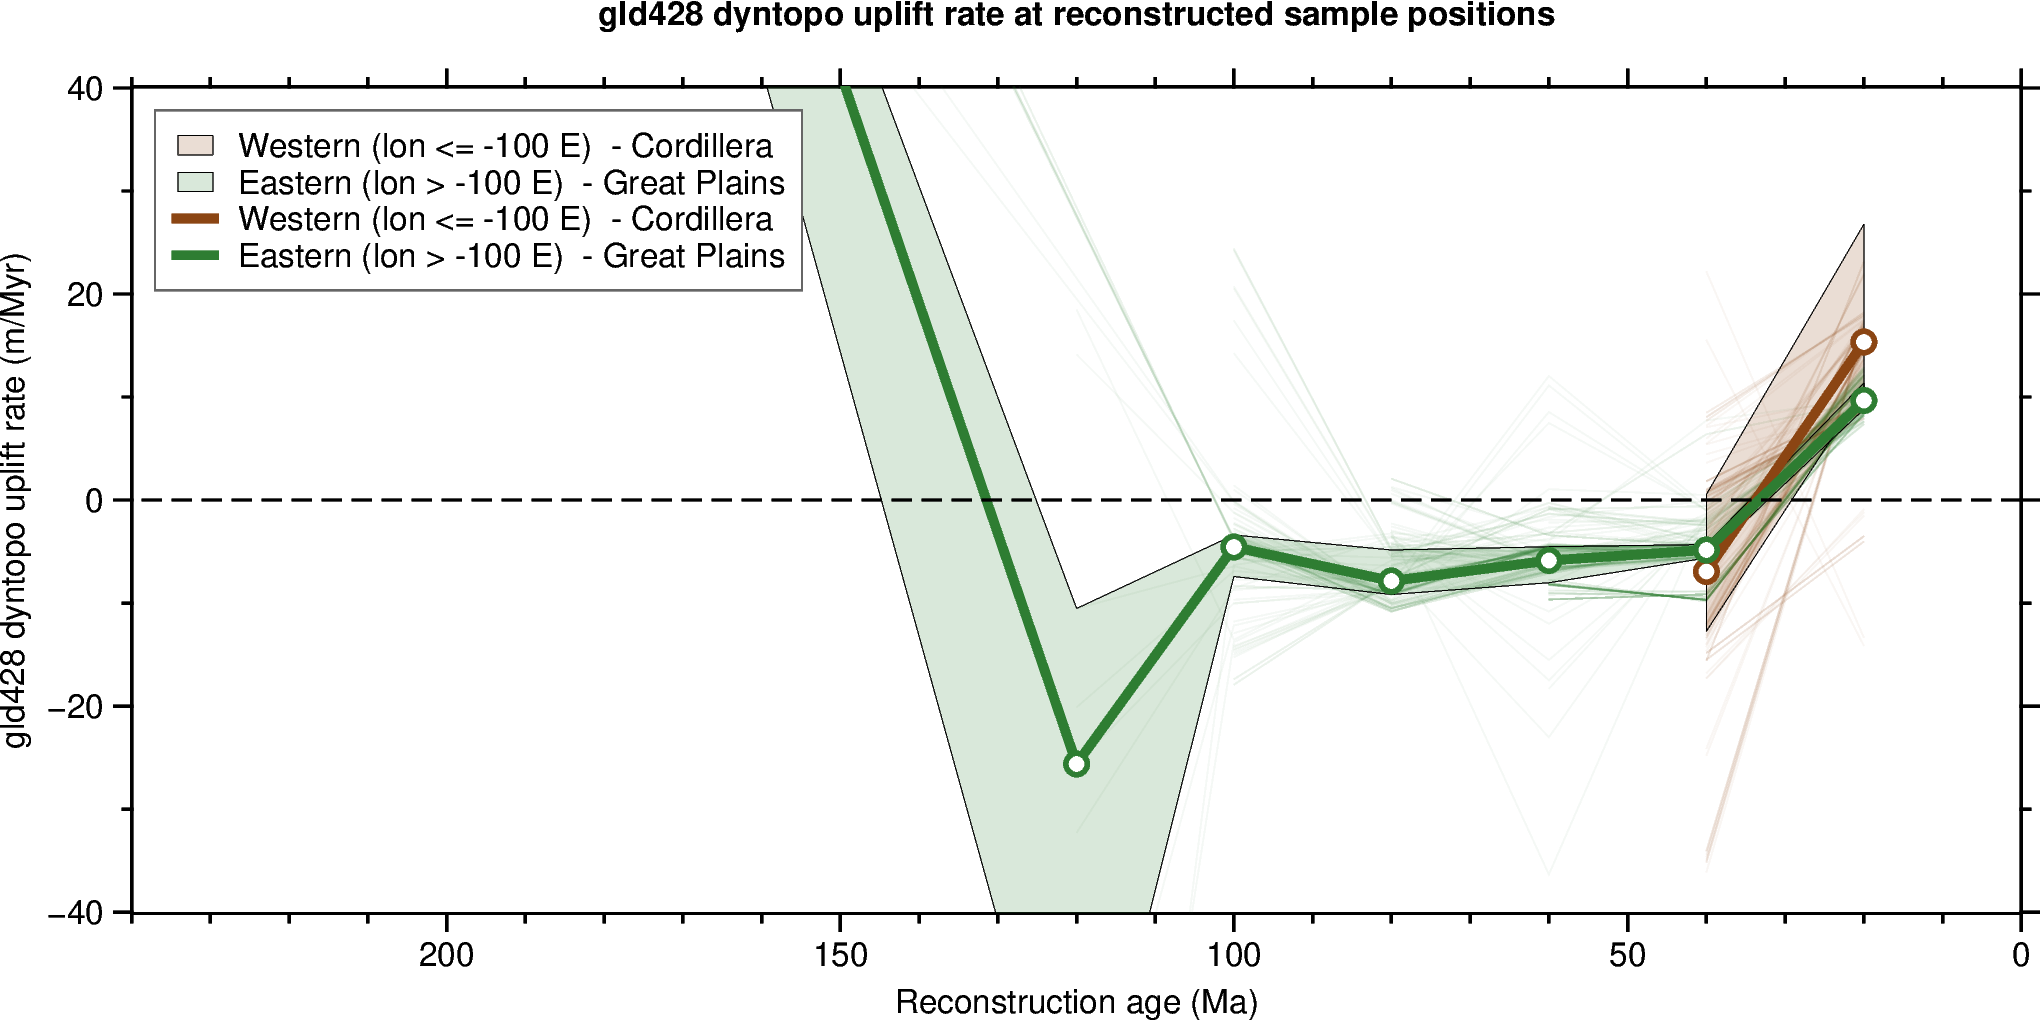

In [10]:
# Pool master parquet files + split W vs E at -100 deg E (Rocky Mountain front)
EW_THRESHOLD_LON = -100.0
frames = []
for a in DYNTOPO_AGES:
    p = dyntopo_master_path(a)
    if not p.exists(): continue
    df = pd.read_parquet(p)
    if "age_Ma" not in df.columns: df["age_Ma"] = float(a)
    frames.append(df)
ts_pool = pd.concat(frames, ignore_index=True)
ts_pool["sector"] = np.where(ts_pool["lon"] <= EW_THRESHOLD_LON, "W", "E")

def summarise(metric_col):
    return (ts_pool.dropna(subset=[metric_col])
                   .groupby(["age_Ma", "sector"])[metric_col]
                   .agg(median="median", q25=lambda s: s.quantile(0.25),
                        q75=lambda s: s.quantile(0.75), n="count").reset_index())
summ_cool = summarise("cooling_rate")
summ_upl  = summarise("uplift_rate_m_per_Myr")

# Colours: brown for the Cordilleran west, green for the cratonic east
sector_colors = {"W": "#8B4513", "E": "#2E7D32"}
sector_labels = {"W": "Western (lon <= -100 E)  - Cordillera, Basin & Range, Colorado Plateau",
                 "E": "Eastern (lon > -100 E)  - Great Plains, Midcontinent, Appalachians"}

_ages_all = ts_pool["age_Ma"].to_numpy(float)
_xmax = float(np.nanmax(_ages_all))

def _band_polygon(x, ylo, yhi):
    x = np.asarray(x, float); ylo = np.asarray(ylo, float); yhi = np.asarray(yhi, float)
    m = np.isfinite(x) & np.isfinite(ylo) & np.isfinite(yhi)
    x, ylo, yhi = x[m], ylo[m], yhi[m]
    return (np.concatenate([x, x[::-1]]),
            np.concatenate([ylo, yhi[::-1]]))

# --- top panel: COOLING RATE (pyGMT) ---
# Tight y-axis: percentile-clipped upper bound so the tail of very-young-age
# samples (closure-to-surface rates near the MAX_TEMPDIFF_CAP_CDEGMYR cap)
# does not force auto-scaling to the cap and flatten the median-IQR band.
_cool_p95 = float(np.nanpercentile(ts_pool["cooling_rate"], 95))
_cool_ymax = max(_cool_p95 * 1.15, 0.5)

fig = pygmt.Figure()
fig.basemap(region=[0, _xmax, 0, _cool_ymax],
            projection="X-16c/7c",
            frame=["WSne+tNA cooling rate vs reconstruction age - W/E split at the Rocky Mountain front",
                   "xaf+lReconstruction age (Ma)", "yaf+lCooling rate (\260C/Myr)"])
# Per-sample thin, faint lines
for sname, g in ts_pool.dropna(subset=["cooling_rate"]).groupby("sample_name"):
    g = g.sort_values("age_Ma"); sec = g["sector"].iloc[0]
    fig.plot(x=g["age_Ma"].to_numpy(float),
             y=g["cooling_rate"].to_numpy(float),
             pen=f"0.3p,{sector_colors[sec]}@95")
# IQR bands
for sec in ("W", "E"):
    sub = summ_cool[summ_cool["sector"] == sec].sort_values("age_Ma")
    _px, _py = _band_polygon(sub["age_Ma"].values, sub["q25"].values, sub["q75"].values)
    if _px.size:
        fig.plot(x=_px, y=_py, fill=f"{sector_colors[sec]}@82", pen="0p",
                 label=f"{sector_labels[sec]}  (IQR)")
# Median lines + open-circle markers
for sec in ("W", "E"):
    sub = summ_cool[summ_cool["sector"] == sec].sort_values("age_Ma")
    fig.plot(x=sub["age_Ma"].values, y=sub["median"].values,
             pen=f"2.2p,{sector_colors[sec]}",
             label=f"{sector_labels[sec]}  (median)")
    fig.plot(x=sub["age_Ma"].values, y=sub["median"].values,
             style="c0.18c", fill="white", pen=f"1.2p,{sector_colors[sec]}")
fig.legend(position="JTL+jTL+o0.2c", box="+gwhite+p0.4p,gray40")
fig.show(width=900)

# --- bottom panel: gld428 UPLIFT RATE (pyGMT) ---
# Symmetric percentile-clipped range so a handful of extreme uplift-rate
# outliers do not compress the median-IQR bands.
_upl_abs_p95 = float(np.nanpercentile(np.abs(ts_pool["uplift_rate_m_per_Myr"]), 95))
_upl_lim = _upl_abs_p95 * 1.15

fig = pygmt.Figure()
fig.basemap(region=[0, _xmax, -_upl_lim, _upl_lim],
            projection="X-16c/7c",
            frame=["WSne+tgld428 dyntopo uplift rate at reconstructed sample positions",
                   "xaf+lReconstruction age (Ma)", "yaf+lgld428 dyntopo uplift rate (m/Myr)"])
for sname, g in ts_pool.dropna(subset=["uplift_rate_m_per_Myr"]).groupby("sample_name"):
    g = g.sort_values("age_Ma"); sec = g["sector"].iloc[0]
    fig.plot(x=g["age_Ma"].to_numpy(float),
             y=g["uplift_rate_m_per_Myr"].to_numpy(float),
             pen=f"0.3p,{sector_colors[sec]}@95")
for sec in ("W", "E"):
    sub = summ_upl[summ_upl["sector"] == sec].sort_values("age_Ma")
    _px, _py = _band_polygon(sub["age_Ma"].values, sub["q25"].values, sub["q75"].values)
    if _px.size:
        fig.plot(x=_px, y=_py, fill=f"{sector_colors[sec]}@82", pen="0p",
                 label=f"{sector_labels[sec]}  (IQR)")
for sec in ("W", "E"):
    sub = summ_upl[summ_upl["sector"] == sec].sort_values("age_Ma")
    fig.plot(x=sub["age_Ma"].values, y=sub["median"].values,
             pen=f"2.2p,{sector_colors[sec]}",
             label=f"{sector_labels[sec]}  (median)")
    fig.plot(x=sub["age_Ma"].values, y=sub["median"].values,
             style="c0.18c", fill="white", pen=f"1.2p,{sector_colors[sec]}")
fig.plot(x=[0, _xmax], y=[0, 0], pen="0.6p,black,--")
fig.legend(position="JTL+jTL+o0.2c", box="+gwhite+p0.4p,gray40")
fig.show(width=900)


In [ ]:
# Pool + Pearson r per age + scatter plot (pyGMT)
frames = [pd.read_parquet(dyntopo_master_path(a))
          for a in DYNTOPO_AGES_CORR if dyntopo_master_path(a).exists()]
pool = pd.concat(frames, ignore_index=True)
pool = pool.dropna(subset=["uplift_rate_m_per_Myr"]).copy()
if "age_Ma" not in pool.columns:
    rows = []
    for a in DYNTOPO_AGES_CORR:
        p = dyntopo_master_path(a)
        if not p.exists(): continue
        df = pd.read_parquet(p); df["age_Ma"] = float(a); rows.append(df)
    pool = pd.concat(rows, ignore_index=True).dropna(subset=["uplift_rate_m_per_Myr"])
print(f"  pooled: {len(pool):,} (sample, age) pairs across "
      f"{pool['age_Ma'].nunique()} ages")


def pearson_r(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3: return np.nan, int(m.sum())
    return float(np.corrcoef(x[m], y[m])[0, 1]), int(m.sum())


r_rows = []
for age, sub in pool.groupby("age_Ma"):
    r, n = pearson_r(sub["uplift_rate_m_per_Myr"].to_numpy(float),
                      sub["cooling_rate"].to_numpy(float))
    r_rows.append({"age_Ma": age, "r_cool_vs_uplift": r, "n": n})
r_by_age = pd.DataFrame(r_rows).sort_values("age_Ma")

# --- top panel: scatter with age-coloured points + regression line (pyGMT) ---
df = pool.dropna(subset=["uplift_rate_m_per_Myr", "cooling_rate"])
_x = df["uplift_rate_m_per_Myr"].to_numpy(float)
_y = df["cooling_rate"].to_numpy(float)
_c = df["age_Ma"].to_numpy(float)
_age_lo = float(min(DYNTOPO_AGES_CORR))
_age_hi = float(max(DYNTOPO_AGES_CORR))
_xmin = float(np.nanmin(_x)); _xmax = float(np.nanmax(_x))
_ymin = float(np.nanmin(_y)); _ymax = float(np.nanmax(_y))
_xpad = max((_xmax - _xmin) * 0.05, 1.0)
_ypad = max((_ymax - _ymin) * 0.05, 0.05)

fig = pygmt.Figure()
pygmt.makecpt(cmap="viridis", series=[_age_lo, _age_hi, 1], continuous=True)
fig.basemap(region=[_xmin - _xpad, _xmax + _xpad, _ymin - _ypad, _ymax + _ypad],
            projection="X16c/8c",
            frame=["WSne", "xaf+lgld428 dyntopo uplift rate (m/Myr) at M21 NNR-reconstructed sample position", "yaf+lNA cooling rate (\260C/Myr)"])
fig.plot(x=_x, y=_y, style="c0.14c", fill=_c, cmap=True, pen="0.15p,black")
# Zero-uplift vertical reference
fig.plot(x=[0, 0], y=[_ymin - _ypad, _ymax + _ypad], pen="0.6p,black,--")
# Regression line
if len(df) > 1:
    slope, intercept = np.polyfit(_x, _y, 1)
    xl = np.linspace(_x.min(), _x.max(), 100)
    fig.plot(x=xl, y=slope * xl + intercept, pen="1.4p,black")
# r annotation
r_all, n_all = pearson_r(_x, _y)
fig.text(text=f"r = {r_all:+.3f}  (n = {n_all:,})",
         position="TL", justify="TL", offset="0.3c/-0.3c",
         font="11p,Helvetica-Bold,black",
         fill="white", pen="0.4p,gray40")
fig.colorbar(frame=["xaf+lReconstruction age (Ma)"],
             position="JMR+o0.6c/0c+w6c/0.35c")
fig.show(width=900)

# --- bottom panel: Pearson r time-series (pyGMT) ---
rmax = max(0.2, r_by_age["r_cool_vs_uplift"].abs().max() if not r_by_age.empty else 0.2)
_xmax_age = float(r_by_age["age_Ma"].max())

fig = pygmt.Figure()
fig.basemap(region=[0, _xmax_age, -rmax, rmax],
            projection="X-16c/6c",
            frame=["WSne", "xaf+lReconstruction age (Ma)", "yaf+lPearson r (cooling rate vs gld428 uplift rate)"])
# Colour bands: positive r on lightcoral, negative on lightsteelblue
fig.plot(x=[0, _xmax_age, _xmax_age, 0], y=[0, 0, rmax, rmax],
         fill="lightcoral@85", pen="0p")
fig.plot(x=[0, _xmax_age, _xmax_age, 0], y=[-rmax, -rmax, 0, 0],
         fill="lightsteelblue@85", pen="0p")
# Zero reference
fig.plot(x=[0, _xmax_age], y=[0, 0], pen="0.6p,black,--")
# r line + open-circle markers
_rx = r_by_age["age_Ma"].to_numpy(float)
_ry = r_by_age["r_cool_vs_uplift"].to_numpy(float)
fig.plot(x=_rx, y=_ry, pen="1.8p,black")
fig.plot(x=_rx, y=_ry, style="c0.22c", fill="white", pen="1.4p,black")
fig.show(width=900)


### Interpreting the r(t) trajectory

For North America the strongest positive `r(t)` signal is expected in the **Late Cretaceous through Paleogene** window (\~100-30 Ma) — the interval where Farallon flat-slab subduction and its detachment drove the largest DT variations across the Cordilleran interior. Persistent positive `r(t)` in that window would be direct statistical evidence that Cordilleran cooling rates were paced by mantle-flow-driven surface uplift — the textbook Farallon story.

**Important caveats**:
- The USGS Geochron closure-to-surface cooling-rate reduction is coarser than Boone et al. (2025)'s per-window `TempDiff`; a sample with a complex t-T history (multi-stage cooling, reheating events) is compressed to a single mean rate. This blurs the correlation compared with a Boone et al.-style analysis on samples that have published inverse thermal-history models. For the \~5-10% of the compilation that DOES have inverse t-T models in the primary literature, an "Extend this" exercise could recompute per-window rates and rerun the correlation for that subset.
- `gld428` at 5-Myr cadence resolves long-wavelength DT well but does not capture rapid events like the Yellowstone-hotspot passage (post-16 Ma) — a plume-suppressed feature in this model. Cooling-rate signal from Yellowstone-influenced samples will not correlate with the gld428 field.
- The plate-model match is respected by construction: samples reconstructed via M21 NNR (the frame `gld428` was run in), and Δz differencing done in the plate frame then rotated to the mantle frame for map display.
- The default 200 Ma cap is set by the useful DT window; the sample density falls off rapidly at Paleozoic ages, and pre-200 Ma North American thermal histories are dominated by processes (Alleghanian orogeny, Iapetus/Rheic subduction) that need a different geodynamic substrate to test properly. See the "Extend this" section below for the 20-Myr / 0-980 Ma swap recipe.


## Extend this

- **Deeper-time exploration with the 20-Myr-cadence 0-980 Ma gld428 subset.** Swap `GLD428_DIR_CANDIDATES` to `data/Young2022_dynamic_topo/plate_frame/20my_0-960Ma/` (filename convention `gld428_PlateFrameGrid<age>.nc`), change `_gld428_path`'s filename formatter to match, bump `DYNTOPO_STEP_MYR` to 20, and raise `MAX_SAMPLE_AGE_MA` to 540 (Phanerozoic) or 980 (into the Neoproterozoic). The rest of the pipeline runs against pre-200 Ma North American cratonic samples unchanged. Note the 20-Myr cadence resolves less of the fast Cordilleran uplift signal, so use it primarily for Paleozoic-Neoproterozoic exploration rather than the Farallon window.
- **Per-window `TempDiff` on the subset with published inverse thermal-history models.** For samples whose primary literature includes QTQt or HeFTy inverse models (\~5-10% of USGS Geochron entries), replace the closure-to-surface reduction in cell 6 with per-window rates read from the published models. The Cordillera Zenodo stack (Kaempfer 2024, Ronemus 2023, Schoettle-Greene 2022, Benowitz 2023, Colgan 2020, Lease 2021) provides the largest single body of open-license inverse t-T histories over the NA-Cordilleran window and would sharpen the DT correlation considerably.
- **Method-stratified correlation.** Restrict the pooled scatter (cell 25) to a single thermochronometer (AHe, AFT, ZHe, or ZFT) to see whether the DT-cooling correlation depends on closure temperature. A cleaner AHe signal would suggest the near-surface unroofing tracks DT most directly; a cleaner AFT signal would push the coupling deeper.
- **Fault-proximity test (T49 template).** The GEM Global Active Faults Database + Utah Geological Survey compilations cover NA well. Mirror T49's proximity-analysis block here: does the fastest-cooling subset preferentially lie within 25 km of active-Cordilleran + Basin-Range faults? Contrast with cratonic-interior samples.
- **Compare against a Farallon-slab reconstruction.** The Sigloch & Mihalynuk (2013) slab-strand reconstruction gives a direct 3-D geometry for the Farallon slab through the Mesozoic. Plot the sample positions against slab depth-slice contours at each snapshot age and test whether cooling rate correlates with vertical slab depth.
- **Extend to the Canadian Shield.** Raise `MAX_SAMPLE_AGE_MA` to 1000 Ma to include Neoproterozoic-aged cratonic samples. `gld428` extends to 980 Ma so the DT context is available; the question is whether AFT/He ages older than 540 Ma preserve any DT-linked signal or whether cratonic thermal histories are dominated by isostatic denudation.

## References

- Hillenbrand, I.W., et al. (2023, rev. 2025). *USGS Geochron: A Database of Geochronological and Thermochronological Dates and Data (ver. 4.0)*. U.S. Geological Survey data release. DOI: 10.5066/P9RZNPIF.
- Boone, S.C. et al. (2025). Deciphering mantle, tectonic, and climate drivers of exhumation from continental-scale thermochronology datasets. *Communications Earth & Environment* 6, 1015. https://doi.org/10.1038/s43247-025-02852-7
- Young, A., Flament, N., Williams, S.E., Merdith, A., Cao, X., Müller, R.D. (2022). Long-term Phanerozoic sea level change from solid Earth processes. *Earth and Planetary Science Letters* 584, 117451.
- Moucha, R., Forte, A.M., Rowley, D.B., Mitrovica, J.X., Simmons, N.A., Grand, S.P. (2008). Mantle convection and the recent evolution of the Colorado Plateau and the Rio Grande Rift Valley. *Geology* 36, 439-442.
- Forte, A.M., Moucha, R., Simmons, N.A., Grand, S.P., Mitrovica, J.X. (2010). Descent of the ancient Farallon slab drives localized mantle flow below the North American surface: evidence from time-varying kinematics of North America and its coastal ocean. *Geophysical Research Letters* 37, L18309.
- Karlstrom, K.E., Coblentz, D., Dueker, K., Ouimet, W., Kirby, E., Van Wijk, J., Schmandt, B., Kelley, S., Lazear, G., Crossey, L.J., et al. (2012). Mantle-driven dynamic uplift of the Rocky Mountains and Colorado Plateau and its surface response: toward a unified hypothesis. *Lithosphere* 4, 3-22.
- Flowers, R.M., Zeitler, P.K., Danišík, M., Reiners, P.W., Gautheron, C., Ketcham, R.A., Metcalf, J.R., Stockli, D.F., Enkelmann, E. and Brown, R.W., 2023. (U-Th)/He chronology: Part 1. Data, uncertainty, and reporting. *Geological Society of America Bulletin*, 135(1-2), pp.104-136.
- Kohn, B.P., Ketcham, R.A., Vermeesch, P., Boone, S.C., Hasebe, N., Chew, D., Bernet, M., Chung, L., Danišík, M., Gleadow, A.J. and Sobel, E.R., 2024. Interpreting and reporting fission-track chronological data. *Geological Society of America Bulletin*, 136(9-10), pp.3891-3920. https://doi.org/10.1130/B37245.1
- Liu, L., Gurnis, M., Seton, M., Saleeby, J., Müller, R.D., Jackson, J.M. (2011). The role of oceanic plateau subduction in the Laramide orogeny. *Nature Geoscience* 3, 353-357.
- Merdith, A.S., Williams, S.E., Collins, A.S., et al. (2021). Extending full-plate tectonic models into deep time. *Earth-Science Reviews* 214, 103477.
